In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import astropy as ast
from astropy.io import ascii
import pandas as pd
import matplotlib.cm as cm
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
#extinction imports
from astropy.table import Table, Column, MaskedColumn, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
# from zh_scraper import get_extinction
# from dustmaps.sfd import SFDQuery
# from dustmaps.edenhofer2023 import Edenhofer2023Query
# sfd = SFDQuery()
# eden = Edenhofer2023Query(integrated=True)
# import sys
# from tqdm import tqdm
# from view_and_clean import individual_plotter, df_extract, individual_plotter_v2, df_extract_v2, offset_corrector
from metrics import sed_plotter, info, observed_sed, largest_amplitude #, fit_plotter_flux, fit_plotter_flux_v2, mean_med_flux, mean_med_flux_v2, offset_warning, offset_warning_v2,compute_lomb_scargle, plot_periodogram, plot_phase_fold 

# Read in files (from pre-computing models, Anna's binary identification files, and the base paths to where you are storing the models)

In [2]:
# for ease of access I created this file that contains RA and DEC columns of both SMC and LMC YSG candidates combined:
coords = pd.read_csv('../merged_smc_lmc_coords_all.csv', comment='#', sep="\\s+", names=['RA', 'DEC'])

df_lmc = pd.read_csv('../ysg_candidates/final_lmc_ysgcands_allphot_simbad.csv', comment='#') # , sep="\\s+"
df_smc = pd.read_csv('../ysg_candidates/final_smc_ysgcands_allphot_simbad.csv', comment='#') # , sep="\\s+"
df_lmc_prefinal = pd.read_csv('../ysg_candidates/prefinal_lmc_ysgcands_allphot_simbad.csv', comment='#') # , sep="\\s+"
df_smc_prefinal = pd.read_csv('../ysg_candidates/prefinal_smc_ysgcands_allphot_simbad.csv', comment='#') # , sep="\\s+"

# now Anna's binary candidates for both clouds:
smc_vis_binaries = pd.read_csv('../ysg_candidates/original_files_from_anna/smc_vis_bin.csv', comment='#')
smc_opt_binaries = pd.read_csv('../ysg_candidates/original_files_from_anna/smc_opt_bin.csv', comment='#') 
lmc_vis_binaries = pd.read_csv('../ysg_candidates/original_files_from_anna/lmc_vis_bin.csv', comment='#')
lmc_opt_binaries = pd.read_csv('../ysg_candidates/original_files_from_anna/lmc_opt_bin.csv', comment='#') 
# this is the file that contains the results of our variability analysis so far! 
# We load it here because it contains Anna's old T and L estimations and my estimations of the dominant period.
stats = pd.read_csv('../summary_results15.csv')
choose_phot = pd.read_csv('choose_surveys_v3.csv', comment='#')
computed_models = pd.read_csv('synth_phot_all_models_allphot_gordon.csv')
# This is the results of fitting for the temperatures (comparing observed to synthetic photometry). Stores the best fits for every star
# temp_stats = pd.read_csv('ysg_temp_fitting_summary_v2.csv') # computations for U-redder, V-redder
temp_stats = pd.read_csv('ysg_temp_fitting_summary_v10_prefinal.csv') # computations for U-redder, B-redder, V-redder
# set serif font settings for plots
plt.rcParams['font.family'] = 'serif'

In [3]:
# load the Gordon extinction curves for LMC and SMC 
lmc_gordon_file = 'dustmaps_data/extinction_curves/lmc_avg_ext.dat'
smc_gordon_file = 'dustmaps_data/extinction_curves/smc_bar_avg.dat'

lmc_gordon = ascii.read(lmc_gordon_file,comment=';',names=['x','AlamAv','unc'])
lmc_Ang = (1./lmc_gordon['x'])*1e4
lmc_wave = np.flip(lmc_Ang)
lmc_AlamAv = np.flip(lmc_gordon['AlamAv'])

smc_gordon = ascii.read(smc_gordon_file,comment=';',names=['x','AlamAv','unc'])
smc_Ang = (1./smc_gordon['x'])*1e4
smc_wave = np.flip(smc_Ang)
smc_AlamAv = np.flip(smc_gordon['AlamAv'])

In [4]:
smcbasepath = './pysynphot_data/grid/bosz/r2000/m-0.75/'
lmcbasepath = './pysynphot_data/grid/bosz/r2000/m-0.25/'
wave=ascii.read('./pysynphot_data/grid/bosz/r2000/bosz2024_wave_r2000.txt', names=['wave'],data_start=0)

# Load in info about the filters (transmissions, zeropoints, and wavelengths)

In [5]:
# Load in filter functions
col_names=['lam','flux']

tmass_j = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.J_v3.0596e-10_ab7.08741e-10_eff12350.dat', names=col_names, data_start=0)
tmass_h = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.H_v1.11064e-10_ab4.00078e-10_eff16620.dat', names=col_names, data_start=0)
tmass_k = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.Ks_v4.17999e-11_ab2.32482e-10_eff21590.dat', names=col_names, data_start=0)

mcps_U=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.U_v4.08739e-9_ab8.23894e-9_eff3706.dat',names=col_names,data_start=0)
mcps_B=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.B_v6.21086e-9_ab5.60999e-9_eff4394.dat', names=col_names,data_start=0)
mcps_V=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.V_v3.64047e-9_ab3.63812e-9_eff5438.dat', names=col_names,data_start=0)
mcps_I=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.I_v9.23651e-10_ab1.45234e-9_eff8568.dat', names=col_names,data_start=0)

swift_uvm1=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVM2_trn_v4.66117e-9_ab2.15291e-8_eff2246.dat', names=col_names,data_start=0)
swift_uvw1=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVW1_trn_v4.02204e-9_ab1.57569e-8_eff2715.dat', names=col_names,data_start=0)
swift_uvw2=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVW2_trn_v5.37469e-9_2.59051e-8_eff2075.dat', names=col_names,data_start=0)  

# Additional bands:
apass_B=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.B.dat', names=col_names,data_start=0)
apass_V=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.V.dat', names=col_names,data_start=0)
apass_g=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.g.dat', names=col_names,data_start=0)
apass_r=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.r.dat', names=col_names,data_start=0)
apass_i=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.i.dat', names=col_names,data_start=0)

smash_U=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.u.dat', names=col_names,data_start=0)
smash_G=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.g.dat', names=col_names,data_start=0)
smash_R=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.r.dat', names=col_names,data_start=0)
smash_I=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.i.dat', names=col_names,data_start=0)
smash_Z=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.z.dat', names=col_names,data_start=0)


# Vega zero points for conversion to ergs/s/cm^2/Angstrom
tmass_j_zp = 3.0596e-10
tmass_h_zp = 1.11064e-10
tmass_k_zp = 4.17999e-11
mcps_U_zp = 4.08739e-9
mcps_B_zp = 6.21086e-9
mcps_V_zp = 3.64047e-9
mcps_I_zp = 9.23651e-10
swift_uvm1_zp = 4.66117e-9
swift_uvw1_zp = 4.02204e-9
swift_uvw2_zp = 5.37469e-9
# Additional bands:
apass_B_zp = 6.72553e-9
apass_V_zp = 3.636e-9
apass_g_zp = 4.92255e-9
apass_r_zp = 2.85425e-9
apass_i_zp = 1.94038e-9

smash_U_zp = 7.48186e-9
smash_G_zp = 4.70792e-9
smash_R_zp = 2.64299e-9
smash_I_zp = 1.78253e-9
smash_Z_zp = 1.29484e-9

apassband_wavelength = [4369.53,
                        5467.57,
                        4671.78,
                        6141.12,
                        7457.89]

smashband_wavelength = [3856.88,
                    4769.90,
                    6370.44,
                    7774.30,
                    9154.88]


# Band wavelengths for plotting
band_wavelengths = {
    'Jmag_2MASS': 12350.0,  
    'Hmag_2MASS': 16620.0,   
    'Kmag_2MASS': 21590.0,   
    'Umag_MCPS': 3706.29,  
    'Bmag_MCPS': 4394.48,      
    'Vmag_MCPS': 5438.23,   
    'Imag_MCPS': 8568.89,     
    'uvm2mag_SWIFT': 2246.56,  
    'uvw1mag_SWIFT': 2715.68,   
    'uvw2mag_SWIFT': 2075.69, 
    'Bmag_APASS': 4369.53,
    'Vmag_APASS': 5467.57,
    'gmag_APASS': 4671.78,
    'rmag_APASS': 6141.12,
    'imag_APASS': 7457.89,
    'Umag_SMASH': 3856.88,
    'gmag_SMASH': 4769.90,
    'rmag_SMASH': 6370.44,
    'imag_SMASH': 7774.30,
    'zmag_SMASH': 9154.88
}

# Defining functions from Maria and Anna for computations...

In [6]:
def observed_sed_allphot(index, coords, df_smc, df_lmc, choose_phot, flux=True, show=False):
    """ 
    Plots the SED for a given index in the coords dataframe
    Modified for multiprocessing - takes dataframes as parameters
    """
    RA = coords['RA'].iloc[index]
    dec = coords['DEC'].iloc[index]
    
    if index < 377:
        row = df_smc[(df_smc['ra'] == RA) & (df_smc['dec'] == dec)]
    elif index >= 377 and index < 848:
        row = df_lmc[(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)] 
    elif index >= 848 and index < 1012:
        row = df_smc_prefinal[(df_smc_prefinal['ra'] == RA) & (df_smc_prefinal['dec'] == dec)] 
    elif index >= 1012:
        row = df_lmc_prefinal[(df_lmc_prefinal['ra'] == RA) & (df_lmc_prefinal['dec'] == dec)]
    
    # Bands and their Vega zero points in erg/s/cm^2/Angstrom
    band_zeropoints = {
    # Near-infrared (2MASS)
    'Jmag_2MASS':3.0596e-10,    # J-band 3.0596e-10 # formerly was 1.11933e-9 
    'Hmag_2MASS':1.11064e-10,    # H-band 1.11064e-10 # formerly was 3.09069e-10 
    'Kmag_2MASS':4.17999e-11,     # K-band 4.17999e-11 # formerly was 4.20615e-11
    # Optical (MCPS)
    'Umag_MCPS':4.08739e-9,    # U-band
    'Bmag_MCPS':6.21086e-9,    # B-band
    'Vmag_MCPS':3.64047e-9,    # V-band
    'Imag_MCPS':9.23651e-10,    # I-band
    # Optical (APASS)
    'Bmag_APASS':6.72553e-9,
    'Vmag_APASS':3.636e-9,
    'gmag_APASS':4.92255e-9,
    'rmag_APASS':2.85425e-9,
    'imag_APASS':1.94038e-9,
    # UV (Swift UVOT)
    'uvw1mag_SWIFT':4.02204e-9,  # UVW
    'uvw2mag_SWIFT':5.37469e-9,   # UVW2
    'uvm2mag_SWIFT':4.66117e-9   # UVM2
    }

    #####  lowercase bands are AB, uppercase are Vega, so be careful with the zeropoints! we will convert the ab mags (g, r, i) from
    ##### APASS to be in VEGA since the rest of the bands are. we would also have to do this for smash. #####
    band_AB_zeropoints = {'gmag_APASS': 4.92255e-9, # ab, g
                            'rmag_APASS': 2.85425e-9, # ab, r
                            'imag_APASS': 1.94038e-9 # ab, i
                            }

    # Effective wavelengths (in Angstroms)
    band_wavelengths = {
        'uvw2mag_SWIFT': 2075.69,    # UV
        'uvm2mag_SWIFT': 2246.56,    # UV
        'uvw1mag_SWIFT': 2715.68,    # UV
        'Umag_MCPS': 3706.29,        # U
        'Bmag_MCPS': 4394.48,        # B
        'Vmag_MCPS': 5438.23,        # V
        'Imag_MCPS': 8568.89,        # I
        'Jmag_2MASS': 12350.00,       # J
        'Hmag_2MASS': 16620.00,       # H
        'Kmag_2MASS': 21590.00,        # K
        'Bmag_APASS': 4369.53,
        'Vmag_APASS': 5467.57,
        'gmag_APASS': 4671.78,
        'rmag_APASS': 6141.12,
        'imag_APASS':7457.89
    }
    
    df = row.iloc[0]
    wavelengths = []
    fluxes = []
    flux_errors = []
    mags = []
    mag_errors = []
    band_names = []
    
    for band in band_zeropoints.keys():
        if band in df.index and not pd.isna(df[band]):
            mag = df[band] # grab the magnitude, but for APASS we will convert to flux and back to mag to ensure consistency with zeropoints and error handling
            error_col = f'e_{band}'
            if error_col in df.index:
                mag_err = df[error_col]
            else:
                mag_err = None

            if mag_err is None or pd.isna(mag_err) or mag_err <= 0:
                mag_err = 0.1  # Default error

            if mag_err < 0.03:
                mag_err = 0.03  # Set minimum error to 0.03 mag

            # if mag_err > 0.36:
            #     # drop the data point if error is too large
            #     band = np.nan
            #     continue

            # Convert magnitude to flux density
            flux_ergs = band_zeropoints[band] * 10**(-0.4 * mag)
            flux_err_ergs = flux_ergs * 0.921 * mag_err

            # Get magnitude and error by converting back from flux, to ensure consistency
            if band in band_AB_zeropoints:
                # For AB magnitudes, use the AB zero point
                mag = -2.5 * np.log10(flux_ergs / band_AB_zeropoints[band])
                if error_col in df.index:
                    mag_err = (2.5 / np.log(10)) * (flux_err_ergs / flux_ergs)  # Convert flux error to magnitude error
            else:
                mag = df[band]
            
            wavelengths.append(band_wavelengths[band])
            fluxes.append(flux_ergs)
            flux_errors.append(flux_err_ergs)
            mags.append(mag)
            mag_errors.append(mag_err)
            band_names.append(band)
    
    # Sort by longest to shortest wavelength
    sorted_indices = np.argsort(wavelengths)[::-1]
    wavelengths = np.array(wavelengths)[sorted_indices]
    fluxes = np.array(fluxes)[sorted_indices]
    flux_errors = np.array(flux_errors)[sorted_indices]
    mags = np.array(mags)[sorted_indices]
    mag_errors = np.array(mag_errors)[sorted_indices]
    # didnt have this line before:
    band_names = np.array(band_names)[sorted_indices]

    return wavelengths, fluxes, flux_errors, mags, mag_errors, band_names

In [7]:
# Functions

def synth_flux(filter_name,model_lam,model_flux):
    '''
    Calculates the synthetic photometric flux for the input model with the
    input filter transmission file.

    Parameters:
    filter_name: The filter file containing the wavelength (Angstroms) 
                    and intensity (erg/s/cm^2/A)
    model_lam: The model wavelengths in Angstroms
    model_flux: The model flux in erg/s/cm^2/A

    Returns:
    flux: The synthetic flux in erg/s/cm^2/A
    '''
    filter_lam = filter_name.columns[0]
    filter_flux = filter_name.columns[1]
    
    f_lam=np.zeros(len(filter_lam))
    for i in range(len(f_lam)):
        # This interpolates the model flux along the same wavelengths as the
        # transmission curve. This needs to be done for the integration to work
        f_lam[i]=np.interp(filter_lam[i],model_lam,model_flux)
    
    # Multiply the (interpolated) model flux by the filter intensity, and integrate
    top = np.trapezoid(np.multiply(f_lam,filter_flux),x=filter_lam)
    # Integrate the filter intensity alone
    bottom = np.trapezoid(filter_flux,x=filter_lam)
    # Divide!
    flux = top/bottom
    
    return flux


def flux_to_mag(flux,zp):
    '''
    Converts a flux to a magnitude given the zero point.

    Parameters:
    flux: flux in erg/s/cm^2/A
    zp: Zero point in erg/s/cm^2/A

    Returns:
    mag: Magnitude
    '''

    mag = (-2.5)*np.log10(flux/zp)

    return mag

def synth_mag(filter_name,model_lam,model_flux,zp):
    '''
    Calculates the synthetic magnitude for the input model using the input
    filter transmission and a zero point.

    Parameters:
    filter_name: The filter file containing the wavelength (Angstroms) 
                    and intensity (erg/s/cm^2/A)
    model_lam: The model wavelengths in Angstroms
    model_flux: The model flux in erg/s/cm^2/A
    zp: Zero point in erg/s/cm^2/A

    Returns:
    mag: Magnitude
    '''

    flux = synth_flux(filter_name,model_lam,model_flux)
    mag = flux_to_mag(flux,zp)
    return mag

def rchi2_with_err(star_mags,star_err,model_mags):
    '''
    Returns the reduced chi^2, accounting for errors
    Parameters:
        star_mags: Observed magnitudes
        star_err: Uncertainty on the observed magnitudes
        model_mags: Model magnitudes
    Returns:
        rchi2: Reduced chi^2 value
    '''
    N = len(star_mags)
    z = (star_mags-model_mags)/star_err
    rchi2 = np.sum(z**2)/(N-1)
    return rchi2

def Cardelli_redden(wave,flux,Av=0,Rv=3.1):
    '''Will redden an input spectrum based on the Cardelli law:
    
    Parameters:
    wave (angstrom): wavelengths of input spectrum in Angstrom
    flux (erg/s/cm/Ang): flux of spectrum; scaled version of this flux are fine.
    Av:
    Rv:
    
    Returns: a new flux array in same units as input
    '''

    wave_micon=wave*1.0e-4
    wave_inverse=1.0/wave_micon
    
    A_lambda=np.zeros(len(wave))
    ax=np.zeros(len(wave))
    bx=np.zeros(len(wave))
    
    for i in range(len(wave)):
        if((wave_inverse[i] > 0.3) and (wave_inverse[i] < 1.1)):
            ax[i]=0.574*wave_inverse[i]**1.61
            bx[i]=-0.527*wave_inverse[i]**1.61
        if((wave_inverse[i] > 1.1) and (wave_inverse[i] < 3.3)):
            y=wave_inverse[i] - 1.82
            ax[i]=1+ 0.17699*y - 0.50447*y**2. - 0.02427*y**3.+0.72085*y**4.+0.01979*y**5.-0.77530*y**6.+0.32999*y**7.
            bx[i]=1.41338*y+2.28305*y**2.+1.07233*y**3.-5.38434*y**4.-0.62251*y**5.+5.30260*y**6.-2.09002*y**7.
        if((wave_inverse[i] > 3.3) and (wave_inverse[i] < 8.0)):
            if(wave_inverse[i] > 5.9):
                Fa=-0.04473*(wave_inverse[i] - 5.9)**2.-0.009779*(wave_inverse[i]-5.9)**3.
                Fb=0.2130*(wave_inverse[i] - 5.9)**2. +0.1207*(wave_inverse[i] -5.9)**3.
            else:
                Fa = 0.0
                Fb = 0.0

            ax[i]=1.752 - 0.316*wave_inverse[i]-0.104/((wave_inverse[i]-4.67)**2.+0.341) +Fa
            bx[i]=-3.090+1.825*wave_inverse[i]+1.206/((wave_inverse[i] - 4.62)**2.+0.263) +Fb

    A_lambda=(ax+bx/Rv)*Av
    #print(A_lambda)
    NewSpec=flux*10.**(-0.4*A_lambda)
    results = NewSpec
    return results

def gordon_redden(wave, flux, Av, wave_gordon, AlamAv):
    """Will redden an input spectrum based on the Gordon's Extinction Curve:

    Parameters:
    wave (angstrom): wavelengths of input spectrum in Angstrom
    flux (erg/s/cm/Ang): flux of spectrum; scaled version of this flux are fine.
    Av: Amount to de-redden by
    wave_gordon (Angstrom): wavelengths associated with the Gordon Curve
    AlamAv: associated array of Alambda/Av values for Gordon curve.

    Returns: a new flux array in same units as input
    """

    # Interpolate Gordone to the wavelengths of Spectrum:
    AlamAv_interp = np.interp(wave,wave_gordon,AlamAv)
    A_lambda = Av * AlamAv_interp

    #############
    NewSpec = flux * 10.0 ** (-0.4 * A_lambda)

    return NewSpec

def compute_synth_photometry(ex_wave, ex_flux):
    jmag=synth_mag(tmass_j,ex_wave['wave'],ex_flux['flux'],tmass_j_zp)
    hmag=synth_mag(tmass_h,ex_wave['wave'],ex_flux['flux'],tmass_h_zp)
    kmag=synth_mag(tmass_k,ex_wave['wave'],ex_flux['flux'],tmass_k_zp)
    Umag=synth_mag(mcps_U,ex_wave['wave'],ex_flux['flux'],mcps_U_zp)
    Bmag=synth_mag(mcps_B,ex_wave['wave'],ex_flux['flux'],mcps_B_zp)
    Vmag=synth_mag(mcps_V,ex_wave['wave'],ex_flux['flux'],mcps_V_zp)
    Imag=synth_mag(mcps_I,ex_wave['wave'],ex_flux['flux'],mcps_I_zp)
    uvm2_mag=synth_mag(swift_uvm1,ex_wave['wave'],ex_flux['flux'],swift_uvm1_zp)
    uvw1_mag=synth_mag(swift_uvw1,ex_wave['wave'],ex_flux['flux'],swift_uvw1_zp)
    uvw2_mag=synth_mag(swift_uvw2,ex_wave['wave'],ex_flux['flux'],swift_uvw2_zp)
    model_mags=[jmag,hmag,kmag,Umag,Bmag,Vmag,Imag,uvm2_mag,uvw1_mag,uvw2_mag]

    #convert them to flux:
    jflux = tmass_j_zp * 10**(-0.4 * jmag)
    hflux = tmass_h_zp * 10**(-0.4 * hmag)
    kflux = tmass_k_zp * 10**(-0.4 * kmag)
    Uflux = mcps_U_zp * 10**(-0.4 * Umag)
    Bflux = mcps_B_zp * 10**(-0.4 * Bmag)
    Vflux = mcps_V_zp * 10**(-0.4 * Vmag)
    Iflux = mcps_I_zp * 10**(-0.4 * Imag)
    uvm2_flux = swift_uvm1_zp * 10**(-0.4 * uvm2_mag)
    uvw1_flux = swift_uvw1_zp * 10**(-0.4 * uvw1_mag)
    uvw2_flux = swift_uvw2_zp * 10**(-0.4 * uvw2_mag)
    model_fluxes=[jflux,hflux,kflux,Uflux,Bflux,Vflux,Iflux,uvm2_flux,uvw1_flux,uvw2_flux]

    # dictionary with band names as keys
    synth_phot = {
        'J': {'mag': jmag, 'flux': jflux},
        'H': {'mag': hmag, 'flux': hflux},
        'K': {'mag': kmag, 'flux': kflux},
        'U': {'mag': Umag, 'flux': Uflux},
        'B': {'mag': Bmag, 'flux': Bflux},
        'V': {'mag': Vmag, 'flux': Vflux},
        'I': {'mag': Imag, 'flux': Iflux},
        'uvm2': {'mag': uvm2_mag, 'flux': uvm2_flux},
        'uvw1': {'mag': uvw1_mag, 'flux': uvw1_flux},
        'uvw2': {'mag': uvw2_mag, 'flux': uvw2_flux}
    }
    return synth_phot

# Main plotting functions to see SEDs and spectra, then histograms, for a given star:

In [8]:
def smash(index):
    RA = coords['RA'].iloc[index]
    dec = coords['DEC'].iloc[index]
    
    if index < 377:
        row = df_smc[(df_smc['ra'] == RA) & (df_smc['dec'] == dec)]
    elif index >= 377 and index < 848:
        row = df_lmc[(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)] 
    elif index >= 848 and index < 1012:
        row = df_smc_prefinal[(df_smc_prefinal['ra'] == RA) & (df_smc_prefinal['dec'] == dec)] 
    elif index >= 1012:
        row = df_lmc_prefinal[(df_lmc_prefinal['ra'] == RA) & (df_lmc_prefinal['dec'] == dec)]
    else:
        raise ValueError(f"Index {index} out of expected range")

    smashmags = []
    smashmag_errs = []
    smashflux_jy = []
    smashflux_err_jy = []

    # Bands and their AB ZEROPOINTS in erg/s/cm^2/Angstrom (in UGRIZ order)
    smashband_zeropoints = {'Umag_SMASH': 7.48186e-9,
                       'Gmag_SMASH': 4.70792e-9,
                       'Rmag_SMASH': 2.64299e-9,
                       'Imag_SMASH': 1.78253e-9,
                       'Zmag_SMASH': 1.29484e-9}

    # Effective wavelengths (in Angstroms) (in UGRIZ order)
    smashband_wavelength = [3856.88,
                       4769.90,
                       6370.44,
                       7774.30,
                       9154.88]
    
    smash_band_names = ['Umag_SMASH', 'Gmag_SMASH', 'Rmag_SMASH', 'Imag_SMASH', 'Zmag_SMASH']

    # do this for UGRIZ mags
    for i, band in enumerate(smash_band_names):
        mag_col = f'{band}'
        err_col = f'e_{band}'
        
        # Check if the SMASH columns exist in the dataframe (they don't exist for prefinal stars)
        if len(row) > 0 and mag_col in row.columns and not pd.isna(row[mag_col].values[0]):
            magvalue = row[mag_col].values[0]
            magerr = row[err_col].values[0]
            
            # Convert magnitude to flux density
            flux_val = smashband_zeropoints[band] * 10**(-0.4 * magvalue)
            flux_err_val = flux_val * 0.921 * magerr
            
            smashmags.append(magvalue)
            smashmag_errs.append(magerr)
            smashflux_jy.append(flux_val)
            smashflux_err_jy.append(flux_err_val)
        else:
            smashmags.append(np.nan)
            smashmag_errs.append(np.nan)
            smashflux_jy.append(np.nan)
            smashflux_err_jy.append(np.nan)
    

    return smashband_wavelength, smashflux_jy, smashflux_err_jy, smashmags, smashmag_errs, smash_band_names, 

# smash_apass(0)

In [9]:
def histo(index):
    RA = coords['RA'].iloc[index]
    dec = coords['DEC'].iloc[index]
    binwidth = 250
    final_teff_U_redder = temp_stats['teff_mean_U_redder'].iloc[index]
    final_teff_V_redder = temp_stats['teff_mean_V_redder'].iloc[index]
    output_filename_U_redder = f'temp_fitting/{RA}_{dec}_U_redder.parquet'
    output_filename_V_redder = f'temp_fitting/{RA}_{dec}_V_redder.parquet'
    # read parquet file:
    model_fitting_U_redder = pd.read_parquet(output_filename_U_redder)
    model_fitting_V_redder = pd.read_parquet(output_filename_V_redder)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    
    # Create bins that properly include the max value
    bins_U_redder = range(min(model_fitting_U_redder['teff']) - (binwidth//2), 
                      max(model_fitting_U_redder['teff']) + binwidth//2 + 1, binwidth)
    bins_V_redder = range(min(model_fitting_V_redder['teff']) - binwidth//2, 
                     max(model_fitting_V_redder['teff']) + binwidth//2 + 1, binwidth)
    bins_U_redder_logg = int((max(model_fitting_U_redder['logg']) - min(model_fitting_U_redder['logg'])) * 2.0)
    bins_V_redder_logg = int((max(model_fitting_V_redder['logg']) - min(model_fitting_V_redder['logg'])) * 2.0)
    # Ensure minimum number of bins
    bins_U_redder_logg = max(bins_U_redder_logg, 1)
    bins_V_redder_logg = max(bins_V_redder_logg, 1)  
    
    # Top row - 'full' plots in blue
    axes[0, 0].hist(model_fitting_U_redder['teff'], bins=bins_U_redder, color='blue', alpha=0.7, edgecolor='black')
    axes[0, 0].annotate(f'Average Teff = {final_teff_U_redder:.0f}K \nAverage $\\chi^2$ = {temp_stats.loc[index, "chi2_U_redder_mean"]:.3f}', xy=(0.5, 0.9), xycoords='axes fraction', fontsize=12)
    axes[0, 0].set_xlabel('$T_{eff}$ (K)', fontsize=16)
    axes[0, 0].set_ylabel('Counts')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].hist(model_fitting_U_redder['logL'], bins=len(bins_U_redder), color='blue', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('log($L/L_{\\odot})$', fontsize=16)
    axes[0, 1].set_ylabel('Counts')
    axes[0, 1].grid(True, alpha=0.3)

    # Define custom bin edges for A_v and log(g)
    av_bins = np.arange(-0.05, 1.15, 0.1)  # Centers on 0, 0.1, 0.2, ..., 1.0
    logg_bins = np.arange(-0.25, 3.75, 0.5)  # Centers on 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0

    axes[0, 2].hist(model_fitting_U_redder['av'], bins=av_bins, color='blue', alpha=0.7, edgecolor='black')
    axes[0, 2].set_xlabel('$A_v$', fontsize=16)
    axes[0, 2].set_ylabel('Counts')
    axes[0, 2].grid(True, alpha=0.3)

    axes[0, 3].hist(model_fitting_U_redder['logg'], bins=logg_bins, color='blue', alpha=0.7, edgecolor='black')
    axes[0, 3].set_xlabel('log(g)', fontsize=16)
    axes[0, 3].set_ylabel('Counts')
    axes[0, 3].grid(True, alpha=0.3)
    
    # Bottom row - 'cut' plots in green
    axes[1, 0].hist(model_fitting_V_redder['teff'], bins=bins_V_redder, color='green', alpha=0.7, edgecolor='black')
    axes[1, 0].annotate(f'Average Teff = {final_teff_V_redder:.0f}K \nAverage $\\chi^2$ = {temp_stats.loc[index, "chi2_V_redder_mean"]:.3f}', xy=(0.5, 0.9), xycoords='axes fraction', fontsize=12)
    axes[1, 0].set_xlabel('$T_{eff}$ (K)', fontsize=16)
    axes[1, 0].set_ylabel('Counts')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].hist(model_fitting_V_redder['logL'], bins=len(bins_V_redder), color='green', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('log($L/L_{\\odot}$)', fontsize=16)
    axes[1, 1].set_ylabel('Counts')
    axes[1, 1].grid(True, alpha=0.3)

    axes[1, 2].hist(model_fitting_V_redder['av'], bins=av_bins, color='green', alpha=0.7, edgecolor='black')
    axes[1, 2].set_xlabel('$A_v$', fontsize=16)
    axes[1, 2].set_ylabel('Counts')
    axes[1, 2].grid(True, alpha=0.3)

    axes[1, 3].hist(model_fitting_V_redder['logg'], bins=logg_bins, color='green', alpha=0.7, edgecolor='black')
    axes[1, 3].set_xlabel('log(g)', fontsize=16)
    axes[1, 3].set_ylabel('Counts')
    axes[1, 3].grid(True, alpha=0.3)
    
    # Add row labels
    fig.text(-0.005, 0.75, 'Fitting to UBVIJHK', rotation=90, fontsize=16, va='center', ha='center')
    fig.text(-0.005, 0.25, 'Fitting to VIJHK', rotation=90, fontsize=16, va='center', ha='center')
    fig.text(0.4,-0.02, f'{RA}, {dec}', fontsize=22)
    
    plt.tight_layout()
    plt.show()

# comment this in if you downloaded the parquet files!
# histo(0)

In [10]:
def fit_models_to_star_flux(star_idx): 
    """
    Fits the best model spectra (the median) to the observed SED of a given star index,
    comparing models based on median parameters from temp_stats.
    Optionally plots the observed SED and best-fit models.
    """  
    RA = coords['RA'].iloc[star_idx]
    dec = coords['DEC'].iloc[star_idx]
    ######### grab the observed SED for the star
    obs = observed_sed_allphot(star_idx, coords, df_smc, df_lmc, choose_phot, flux=True, show=False)
    obs_wavelengths, obs_fluxes, obs_flux_errors, obs_mags, obs_mag_errors, obs_band_names = obs

    smash_wavelengths, smash_fluxes, smash_flux_errors, smash_mags, smash_mag_errors, smash_band_names = smash(star_idx)
    valid_smash_indices = [i for i, flux in enumerate(smash_fluxes) if not np.isnan(flux)]
    smash_band_names_valid = [smash_band_names[i] for i in valid_smash_indices]
    smash_wavelengths_valid = [smash_wavelengths[i] for i in valid_smash_indices]

    available_bands = list(obs_band_names)  # Convert to list to ensure .index() method works
    band_to_filter = {
    'Jmag_2MASS': tmass_j, 'Hmag_2MASS': tmass_h, 'Kmag_2MASS': tmass_k,
    'Umag_MCPS': mcps_U, 'Bmag_MCPS': mcps_B, 'Vmag_MCPS': mcps_V, 'Imag_MCPS': mcps_I,
    'Bmag_APASS': apass_B, 'Vmag_APASS': apass_V, 'gmag_APASS': apass_g, 
    'rmag_APASS': apass_r, 'imag_APASS': apass_i,
    'uvm2mag_SWIFT': swift_uvm1, 'uvw1mag_SWIFT': swift_uvw1, 'uvw2mag_SWIFT': swift_uvw2,
    'Umag_SMASH': smash_U, 'Gmag_SMASH': smash_G, 'Rmag_SMASH': smash_R, 
   'Imag_SMASH': smash_I, 'Zmag_SMASH': smash_Z
    }

    ########## determine the best fitting model to test based on medians in ysg_temp_fitting_summary_vX.csv
    # Best fitting U-redder parameters:
    median_teff_U_redder = temp_stats['teff_median_U_redder'][star_idx]
    median_logg_U_redder_raw = temp_stats['logg_median_U_redder'][star_idx]
    median_logg_U_redder = round(np.round(median_logg_U_redder_raw / 0.5) * 0.5, 2)  # Round to nearest 0.5 for model lookup
    median_av_U_redder_raw = temp_stats['av_median_U_redder'][star_idx]  # Keep raw value for display
    median_av_U_redder = round(np.round(median_av_U_redder_raw / 0.05) * 0.05, 2)  # Round to nearest 0.05 for model lookup
    median_metallicity = -0.75 if RA < 40 else -0.25 # SMC if index < 377, else LMC
    
    # Best fitting B-redder parameters:
    median_teff_B_redder = temp_stats['teff_median_B_redder'][star_idx]
    median_logg_B_redder_raw = temp_stats['logg_median_B_redder'][star_idx]
    median_logg_B_redder = round(np.round(median_logg_B_redder_raw / 0.5) * 0.5, 2)  # Round to nearest 0.5 for model lookup
    median_av_B_redder_raw = temp_stats['av_median_B_redder'][star_idx]  # Keep raw value for display
    median_av_B_redder = round(np.round(median_av_B_redder_raw / 0.05) * 0.05, 2)  # Round to nearest 0.05 for model lookup

    #Best fitting V-redder parameters:
    median_teff_V_redder = temp_stats['teff_median_V_redder'][star_idx]
    median_logg_V_redder_raw = temp_stats['logg_median_V_redder'][star_idx]
    median_logg_V_redder = round(np.round(median_logg_V_redder_raw / 0.5) * 0.5, 2)  # Round to nearest 0.5 for model lookup
    median_av_V_redder_raw = temp_stats['av_median_V_redder'][star_idx]  # Keep raw value for display
    median_av_V_redder = round(np.round(median_av_V_redder_raw / 0.05) * 0.05, 2)  # Round to nearest 0.05 for model lookup

    # Filter models based on median parameters - separate the two model sets properly
    # Use rounded Av values for exact model lookup
    models_U_redder = computed_models[
        (computed_models['teff'] == median_teff_U_redder) &
        (computed_models['logg'] == median_logg_U_redder) &
        (computed_models['av'] == median_av_U_redder) &
        (computed_models['metallicity'] == median_metallicity)
    ]
    models_B_redder = computed_models[
        (computed_models['teff'] == median_teff_B_redder) &
        (computed_models['logg'] == median_logg_B_redder) &
        (computed_models['av'] == median_av_B_redder) &
        (computed_models['metallicity'] == median_metallicity)
    ]
    models_V_redder = computed_models[
        (computed_models['teff'] == median_teff_V_redder) &
        (computed_models['logg'] == median_logg_V_redder) &
        (computed_models['av'] == median_av_V_redder) &
        (computed_models['metallicity'] == median_metallicity)
    ]
    plot_data = []
    
    # Process all models (full, B-redder and V-redder)
    for model_type, models in [('V_redder', models_V_redder), ('B_redder', models_B_redder), ('U_redder', models_U_redder)]:
        if len(models) == 0:
            print(f"No models found for {model_type}")
            print(f"  Parameters: Teff={median_teff_V_redder if model_type=='V_redder' else (median_teff_B_redder if model_type=='B_redder' else median_teff_U_redder)}, logg={median_logg_V_redder if model_type=='V_redder' else (median_logg_B_redder if model_type=='B_redder' else median_logg_U_redder)}, Av={median_av_V_redder if model_type=='V_redder' else (median_av_B_redder if model_type=='B_redder' else median_av_U_redder)}, metallicity={median_metallicity}")
            continue
        # take the first (should be only) model
        model = models.iloc[0]
        
        # load model spectrum
        model_spectrum = ascii.read(model['model'], names=['flux','cont'], data_start=0)
        # model_flux = Cardelli_redden(wave['wave'], model_spectrum['flux'], Av=model['av'])
        if star_idx < 377:
            model_flux = gordon_redden(wave['wave'], model_spectrum['flux'], Av=model['av'], wave_gordon=smc_wave, AlamAv=smc_AlamAv)
            simbad_maintype = df_smc['main_type'][(df_smc['ra'] == RA) & (df_smc['dec'] == dec)].values[0]
            simbad_spectype = df_smc['sp_type'][(df_smc['ra'] == RA) & (df_smc['dec'] == dec)].values[0]
            distance = df_smc['angDist'][(df_smc['ra'] == RA) & (df_smc['dec'] == dec)].values[0]
        elif star_idx >= 377 and star_idx < 848:
            model_flux = gordon_redden(wave['wave'], model_spectrum['flux'], Av=model['av'], wave_gordon=lmc_wave, AlamAv=lmc_AlamAv)
            simbad_maintype = df_lmc['main_type'][(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)].values[0]
            simbad_spectype = df_lmc['sp_type'][(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)].values[0]
            distance = df_lmc['angDist'][(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)].values[0]
        elif star_idx >= 848 and star_idx < 1012:
            model_flux = gordon_redden(wave['wave'], model_spectrum['flux'], Av=model['av'], wave_gordon=smc_wave, AlamAv=smc_AlamAv)
            simbad_maintype = df_smc_prefinal['main_type'][(df_smc_prefinal['ra'] == RA) & (df_smc_prefinal['dec'] == dec)].values[0]
            simbad_spectype = df_smc_prefinal['sp_type'][(df_smc_prefinal['ra'] == RA) & (df_smc_prefinal['dec'] == dec)].values[0]
            distance = df_smc_prefinal['angDist'][(df_smc_prefinal['ra'] == RA) & (df_smc_prefinal['dec'] == dec)].values[0]
        elif star_idx >= 1012:
            model_flux = gordon_redden(wave['wave'], model_spectrum['flux'], Av=model['av'], wave_gordon=lmc_wave, AlamAv=lmc_AlamAv)
            simbad_maintype = df_lmc_prefinal['main_type'][(df_lmc_prefinal['ra'] == RA) & (df_lmc_prefinal['dec'] == dec)].values[0]
            simbad_spectype = df_lmc_prefinal['sp_type'][(df_lmc_prefinal['ra'] == RA) & (df_lmc_prefinal['dec'] == dec)].values[0]
            distance = df_lmc_prefinal['angDist'][(df_lmc_prefinal['ra'] == RA) & (df_lmc_prefinal['dec'] == dec)].values[0]

        
        # calculate synthetic fluxes for available bands using the model
        model_fluxes = np.array([synth_flux(band_to_filter[band], wave['wave'], model_flux) for band in available_bands])
        smash_model_fluxes = np.array([synth_flux(band_to_filter[band], wave['wave'], model_flux) for band in smash_band_names_valid])
        
        # Determine reference band for flux scaling (prefer K, then H)
        if 'Kmag_2MASS' in available_bands:
            ref_band = 'Kmag_2MASS'
        else:
            print('No K band found in observed bands.')
            return
        
        ref_idx = available_bands.index(ref_band)
        
        # Calculate scaling factor using reference band
        flux_scale = obs_fluxes[ref_idx] / model_fluxes[ref_idx]
        
        # Scale model fluxes and spectrum
        scaled_model_fluxes = model_fluxes * flux_scale
        scaled_smash_model_fluxes = smash_model_fluxes * flux_scale
        scaled_model_spectrum = model_flux * flux_scale
        
        # Calculate luminosity from scaling
        luminosity = model['lum_unscaled'] * flux_scale
        logL = np.log10(luminosity / 3.826e33)  # solar lum in erg/s
        
        # Get wavelengths for plotting
        plot_wavelengths = [band_wavelengths[band] for band in available_bands]
        plot_smash_wavelengths = smash_wavelengths_valid
        
        # Store data for plotting
        plot_data.append({
            'model_type': model_type,
            'model': model,
            'scaled_model_fluxes': scaled_model_fluxes,
            'scaled_model_spectrum': scaled_model_spectrum,
            'plot_wavelengths': plot_wavelengths,
            # 'scaled_smash_model_fluxes': scaled_smash_model_fluxes,
            'plot_smash_wavelengths': plot_smash_wavelengths,
            # 'obs_fluxes': obs_fluxes,
            'available_bands': available_bands,
            'logL': logL,
            'luminosity': luminosity,
            'scaled_smash_model_fluxes': scaled_smash_model_fluxes
        })

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    # inset axes in the lower right corner
    axins = inset_axes(ax, width="35%", height="35%", loc='upper right')

    bands_used = temp_stats['bands_used_for_fitting'].iloc[star_idx].split(',')
    print(f'bands used: {bands_used}')
    print(f'chi2 values: U-redder={temp_stats["chi2_U_redder_mean"].iloc[star_idx]:.3f}, B-redder={temp_stats["chi2_B_redder_mean"].iloc[star_idx]:.3f}, V-redder={temp_stats["chi2_V_redder_mean"].iloc[star_idx]:.3f}')

    # In your plotting loop
    for i, (wl, flux, errs, band) in enumerate(zip(obs_wavelengths, obs_fluxes, obs_flux_errors, obs_band_names)):
        if band in bands_used:
            color = 'lightblue'
        else:
            color = 'gray'
        ax.errorbar(wl, flux,  yerr=errs, mfc=color,ecolor=color, ms=10,  fmt='*', mec='black', zorder = 12)
    
    # Plot V-redder synthetic photometry
    data_V_redder = plot_data[0]
    ax.plot(data_V_redder['plot_wavelengths'], data_V_redder['scaled_model_fluxes'],
            'o', ms=10, mec='k', mfc='red', alpha=0.9, label='V-redder Synth Phot, Teff={:.0f}K'.format(data_V_redder['model']['teff']), zorder=8)
    ax.plot(data_V_redder['plot_smash_wavelengths'], data_V_redder['scaled_smash_model_fluxes'],
            's', ms=8, mec='k', mfc='red', alpha=0.9, label='SMASH Model Points', zorder=8)

    # Plot B-redder synthetic photometry
    data_B_redder = plot_data[1]
    ax.plot(data_B_redder['plot_wavelengths'], data_B_redder['scaled_model_fluxes'],
            'o', ms=10, mec='k', mfc='yellow', alpha=0.9, label='B-redder Synth Phot, Teff={:.0f}K'.format(data_B_redder['model']['teff']), zorder=8)
    ax.plot(data_B_redder['plot_smash_wavelengths'], data_B_redder['scaled_smash_model_fluxes'],
            's', ms=8, mec='k', mfc='yellow', alpha=0.9, label='SMASH Model Points', zorder=8)
    
    # Plot U-redder synthetic photometry
    data_U_redder = plot_data[2] 
    ax.plot(data_U_redder['plot_wavelengths'], data_U_redder['scaled_model_fluxes'],
            'o', ms=10, mec='k', mfc='blue', alpha=0.9, label='U-redder Synth Phot, Teff={:.0f}K'.format(data_U_redder['model']['teff']), zorder=8)
    ax.plot(data_U_redder['plot_smash_wavelengths'], data_U_redder['scaled_smash_model_fluxes'],
            's', ms=8, mec='k', mfc='blue', alpha=0.9, label='SMASH Model Points', zorder=8)

    # band labels for observed points
    for i, (wl, flux, band) in enumerate(zip(obs_wavelengths, obs_fluxes, obs_band_names)):
        ax.annotate(band, (wl, flux), xytext=(5, 5), textcoords='offset points', 
                    fontsize=8, alpha=0.7)
        
    for i, (wl, flux, band) in enumerate(zip(obs_wavelengths, obs_fluxes, obs_band_names)):
        axins.annotate(band, (wl, flux), xytext=(5, 5), textcoords='offset points', 
                    fontsize=8, alpha=0.7)
    
    # model spectra in background
    ax.plot(wave['wave'], data_V_redder['scaled_model_spectrum'],
            '-', color='red', alpha=0.6, label='V-redder Spectrum', zorder=5)
    ax.plot(wave['wave'], data_B_redder['scaled_model_spectrum'],
            '-', color='yellow', alpha=0.6, label='B-redder Model Spectrum', zorder=5)
    ax.plot(wave['wave'], data_U_redder['scaled_model_spectrum'],
            '-', color='blue', alpha=0.6, label='U-redder Model Spectrum', zorder=5)
    ax.grid(True, alpha=0.3)

    for i, (wl, flux, errs, band) in enumerate(zip(obs_wavelengths, obs_fluxes, obs_flux_errors, obs_band_names)):
        if band in bands_used:
            color = 'lightblue'
        else:
            color = 'gray'
        axins.errorbar(wl, flux,  yerr=errs, mfc=color, ms=10,  fmt='*', mec='black', zorder = 12)
    
    axins.plot(data_V_redder['plot_wavelengths'], data_V_redder['scaled_model_fluxes'],
            'o', ms=8, mec='k', mfc='red', alpha=0.7, zorder=8)
    axins.plot(data_V_redder['plot_smash_wavelengths'], data_V_redder['scaled_smash_model_fluxes'],
            's', ms=6, mec='k', mfc='red', alpha=0.7, zorder=8)

    axins.plot(data_B_redder['plot_wavelengths'], data_B_redder['scaled_model_fluxes'],
        'o', ms=8, mec='k', mfc='yellow', alpha=0.7, zorder=8)
    axins.plot(data_B_redder['plot_smash_wavelengths'], data_B_redder['scaled_smash_model_fluxes'],
            's', ms=6, mec='k', mfc='yellow', alpha=0.7, zorder=8)

    axins.plot(data_U_redder['plot_wavelengths'], data_U_redder['scaled_model_fluxes'],
        'o', ms=8, mec='k', mfc='blue', alpha=0.7, zorder=8)
    axins.plot(data_U_redder['plot_smash_wavelengths'], data_U_redder['scaled_smash_model_fluxes'],
            's', ms=6, mec='k', mfc='blue', alpha=0.7, zorder=8)

    axins.plot(wave['wave'], data_V_redder['scaled_model_spectrum'],
            '-', color='red', alpha=0.6, label='V-redder Model Spectrum', zorder=5)
    axins.plot(wave['wave'], data_B_redder['scaled_model_spectrum'],
            '-', color='yellow', alpha=0.6, label='B-redder Model Spectrum', zorder=5)
    axins.plot(wave['wave'], data_U_redder['scaled_model_spectrum'],
            '-', color='blue', alpha=0.6, label='U-redder Model Spectrum', zorder=5)

    # Set zoom limits around U band
    axins.set_xlim(3500, 4800) 
    # Get U band flux values specifically - with error handling for missing bands
    try:
        u_idx_V_redder = data_V_redder['available_bands'].index('Vmag_MCPS')
        u_idx_B_redder = data_B_redder['available_bands'].index('Bmag_MCPS')
        u_idx_U_redder = data_U_redder['available_bands'].index('Umag_MCPS')
        u_obs_match = np.where(obs_band_names == 'Umag_MCPS')[0]
        
        if len(u_obs_match) > 0:
            u_idx_obs = u_obs_match[0]
            
            u_fluxes = [
                data_V_redder['scaled_model_fluxes'][u_idx_V_redder],
                data_B_redder['scaled_model_fluxes'][u_idx_B_redder],
                data_U_redder['scaled_model_fluxes'][u_idx_U_redder],
                obs_fluxes[u_idx_obs]
            ]
            
            minimum, maximum = np.min(u_fluxes) * 0.5, np.max(u_fluxes) * 2.0  
            axins.set_ylim(minimum, maximum)
        else:
            # If U band not in observations, use all available flux values for zoom
            all_visible_fluxes = [f for f in obs_fluxes if 10**(-15) < f < 10**(-12)]
            if len(all_visible_fluxes) > 0:
                minimum, maximum = np.min(all_visible_fluxes) * 0.5, np.max(all_visible_fluxes) * 2.0
                axins.set_ylim(minimum, maximum)
    except (ValueError, IndexError):
        # If any required bands are missing, set reasonable default limits
        axins.set_ylim(10**(-15), 10**(-13))
    
    axins.set_yscale('log')
    axins.set_xscale('log')
    # Remove all tick labels and ticks - must be done AFTER setting scales
    axins.set_xticks([])
    axins.set_yticks([])
    axins.tick_params(axis='both', which='both', bottom=False, top=False, 
                        left=False, right=False, labelbottom=False, labeltop=False,
                        labelleft=False, labelright=False, length=0)
    # Add title to inset
    axins.set_xlabel('U and B zoom-in', fontsize=12, labelpad=5) 
    
    # Plot additional models within +/-500K range
    for model_type, main_data, color in [('V_redder', data_V_redder, 'gold'), ('B_redder', data_B_redder, 'violet'), ('U_redder', data_U_redder, 'cyan')]:
        best_teff = main_data['model']['teff']
        best_logg = main_data['model']['logg']
        best_av = main_data['model']['av']
        best_metallicity = main_data['model']['metallicity']
        
        # Determine temperature increment based on the model grid: 250K below 12000K, 500K at/above 12000K
        if best_teff < 12000:
            temp_increment = 250
        else:
            temp_increment = 500
        
        # Find temperature variants: one below and one above the best fit
        temp_low = best_teff - temp_increment
        temp_high = best_teff + temp_increment
        
        # Determine allowed logg values based on temperature
        # At 12000K: logg can be 2.5 or 3.0
        # At 12500K and above: only logg = 3.0 is possible
        allowed_logg = [best_logg]  # Always include the best fit logg
        
        if temp_low == 12000 or temp_high == 12000:
            # At 12000K, allow both 2.5 and 3.0
            if 2.5 not in allowed_logg:
                allowed_logg.append(2.5)
            if 3.0 not in allowed_logg:
                allowed_logg.append(3.0)
        elif temp_high >= 12500:
            # At 12500K and above, only logg=3.0
            allowed_logg = [3.0]
        
        temp_models = computed_models[
            ((computed_models['teff'] == temp_low) | (computed_models['teff'] == temp_high)) &
            (computed_models['logg'].isin(allowed_logg)) &  # Surface gravity in allowed range
            (computed_models['av'] == best_av) &       # Same extinction
            (computed_models['metallicity'] == best_metallicity)
        ]

    ######### NEW PHOTOMETRY FROM SMASH

    ax.errorbar(smash_wavelengths, smash_fluxes, yerr=smash_flux_errors,
                ms=10, fmt='*', mec='palevioletred', mfc='lightpink', ecolor='k', label='SMASH', zorder=10)
    axins.errorbar(smash_wavelengths, smash_fluxes, yerr=smash_flux_errors,
                ms=10, fmt='*', mec='palevioletred', mfc='lightpink', ecolor='k', label='SMASH', zorder=10)
    
    # Check if star is in binary candidate files
    tolerance = 1e-5  # Small tolerance for coordinate matching
    in_optsmc = ((np.abs(smc_opt_binaries['ra'] - RA) < tolerance) & 
                (np.abs(smc_opt_binaries['dec'] - dec) < tolerance)).any()
    in_optlmc = ((np.abs(lmc_opt_binaries['ra'] - RA) < tolerance) & 
                (np.abs(lmc_opt_binaries['dec'] - dec) < tolerance)).any()
    in_vissmc = ((np.abs(smc_vis_binaries['ra'] - RA) < tolerance) & 
                (np.abs(smc_vis_binaries['dec'] - dec) < tolerance)).any()
    in_vislmc = ((np.abs(lmc_vis_binaries['ra'] - RA) < tolerance) & 
                (np.abs(lmc_vis_binaries['dec'] - dec) < tolerance)).any()
    in_binary_files = "yes" if (in_optsmc or in_vissmc or in_optlmc or in_vislmc) else "no"

    if star_idx < 848: 
        amp = largest_amplitude(star_idx)[1]
    else:
        amp = np.nan
    if temp_stats.iloc[star_idx]['use_U'] == True:
        fitmodel_to_use = 'U-redder'
    elif temp_stats.iloc[star_idx]['use_B'] == True:
        fitmodel_to_use = 'B-redder'
    elif temp_stats.iloc[star_idx]['use_V'] == True:
        fitmodel_to_use = 'V-redder'

    # Add annotation with both model parameters - use raw (unrounded) Av values for display
    annotation_text = ('V-redder Model: Teff={:.0f}K, Mean Teff={:.0f} $\\pm$ {:.0f}K, logL={:.2f}, logg={:.1f}, Av={:.3f}\n'
                        'B-redder Model: Teff={:.0f}K, Mean Teff={:.0f} $\\pm$ {:.0f}K, logL={:.2f}, logg={:.1f}, Av={:.3f}\n'
                        'U-redder Model: Teff={:.0f}K, Mean Teff={:.0f} $\\pm$ {:.0f}K, logL={:.2f}, logg={:.1f}, Av={:.3f}\n'
                        'SIMBAD: Main Type = {}, Spec Type {}, Distance = {:.2f} arcsec\n'
                        'Model chosen: {}\n'
                        'Variability Amplitude: {:.2f} mag\n'
                        'In binary files: {}').format(
                        data_V_redder['model']['teff'], temp_stats.iloc[star_idx]['teff_mean_V_redder'], temp_stats.iloc[star_idx]['teff_std_V_redder'], data_V_redder['logL'], data_V_redder['model']['logg'], median_av_V_redder_raw,
                        data_B_redder['model']['teff'], temp_stats.iloc[star_idx]['teff_mean_B_redder'], temp_stats.iloc[star_idx]['teff_std_B_redder'], data_B_redder['logL'], data_B_redder['model']['logg'], median_av_B_redder_raw,
                        data_U_redder['model']['teff'], temp_stats.iloc[star_idx]['teff_mean_U_redder'], temp_stats.iloc[star_idx]['teff_std_U_redder'], data_U_redder['logL'], data_U_redder['model']['logg'], median_av_U_redder_raw,
                        simbad_maintype, simbad_spectype, distance,
                        fitmodel_to_use,
                        amp,
                        in_binary_files)
    
    ax.annotate(annotation_text, xy=(0.01, 0.17), xycoords='axes fraction', 
                va='top', color='black', fontsize=9, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), zorder=13)
    chi2_annotation = (f'$\\chi^2$ Values:\n'
                       f'V-redder: {temp_stats.iloc[star_idx]["chi2_V_redder"]:.2f}\n'
                       f'B-redder: {temp_stats.iloc[star_idx]["chi2_B_redder"]:.2f}\n'
                       f'U-redder: {temp_stats.iloc[star_idx]["chi2_U_redder"]:.2f}')
    ax.annotate(chi2_annotation, xy=(0.87, 0.01), xycoords='axes fraction', #  xy=(0.82, 0.87) 
            va='bottom', color='black', fontsize=9, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    ax.set_xlabel(r'Wavelength ($\AA$)')
    ax.set_ylabel(r'Flux (erg/s/cm$^{2}$/$\AA$)')
    ax.set_title(f'{RA}, {dec}; {star_idx} - Median Model Comparison: V-redder vs B-redder vs U-redder Fitting')
    ax.set_xlim(1000, 25000)
    ax.set_yscale('log')
    y_min = min(np.min(data_V_redder['scaled_model_fluxes']), np.min(data_B_redder['scaled_model_fluxes']), np.min(data_U_redder['scaled_model_fluxes']))
    # ax.set_ylim(bottom=np.log10(y_min)*1E4, top=np.log10(1))  # Set y-limits to show 4 orders of magnitude above the minimum flux
    ax.set_ylim(10**(-16), 10**(-13))
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    return

bands used: ['Kmag_2MASS', 'Hmag_2MASS', 'Jmag_2MASS', 'Umag_MCPS', 'Bmag_MCPS', 'Vmag_MCPS', 'Imag_MCPS', 'Bmag_APASS', 'Vmag_APASS', 'gmag_APASS', 'rmag_APASS', 'imag_APASS']
chi2 values: U-redder=1511.517, B-redder=313.285, V-redder=44.462
	Largest amplitude of variability (g-band: True): 2.21 mJy, 0.16 mags
Number of excluded points for star 40 in V-redder: 0, most common band excluded: Imag_MCPS


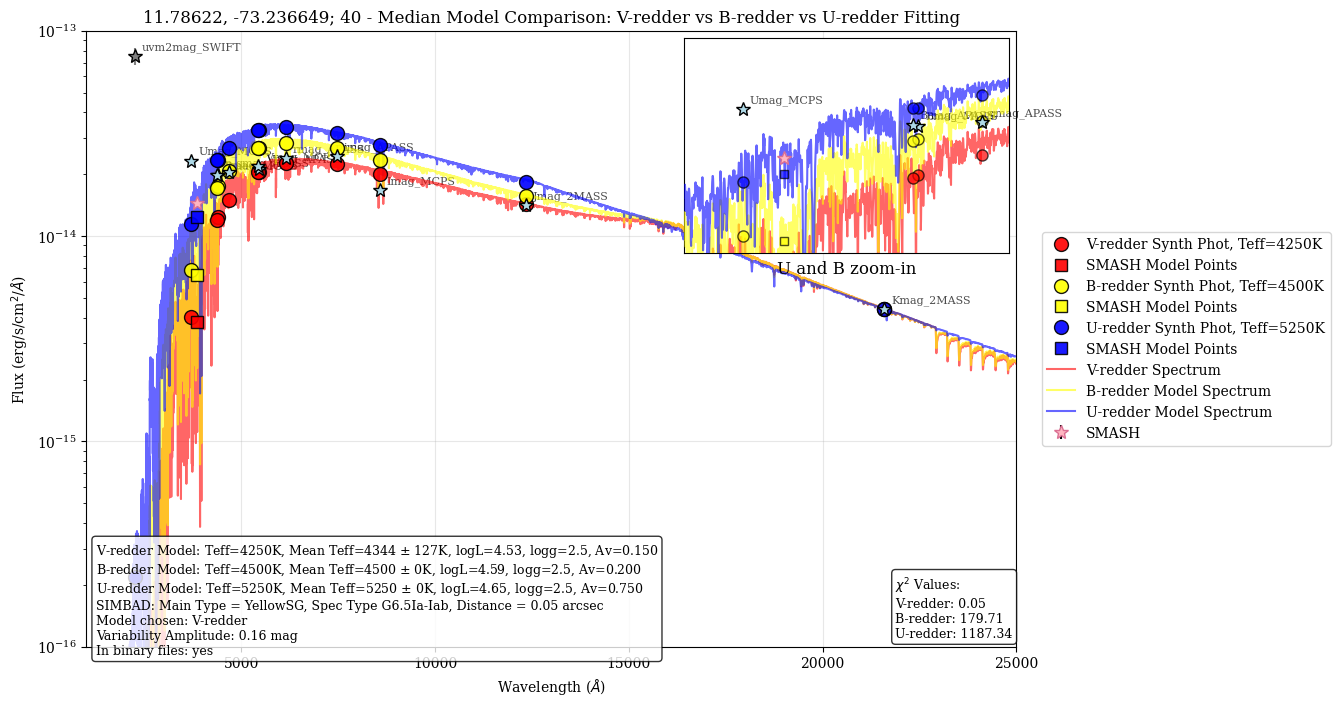

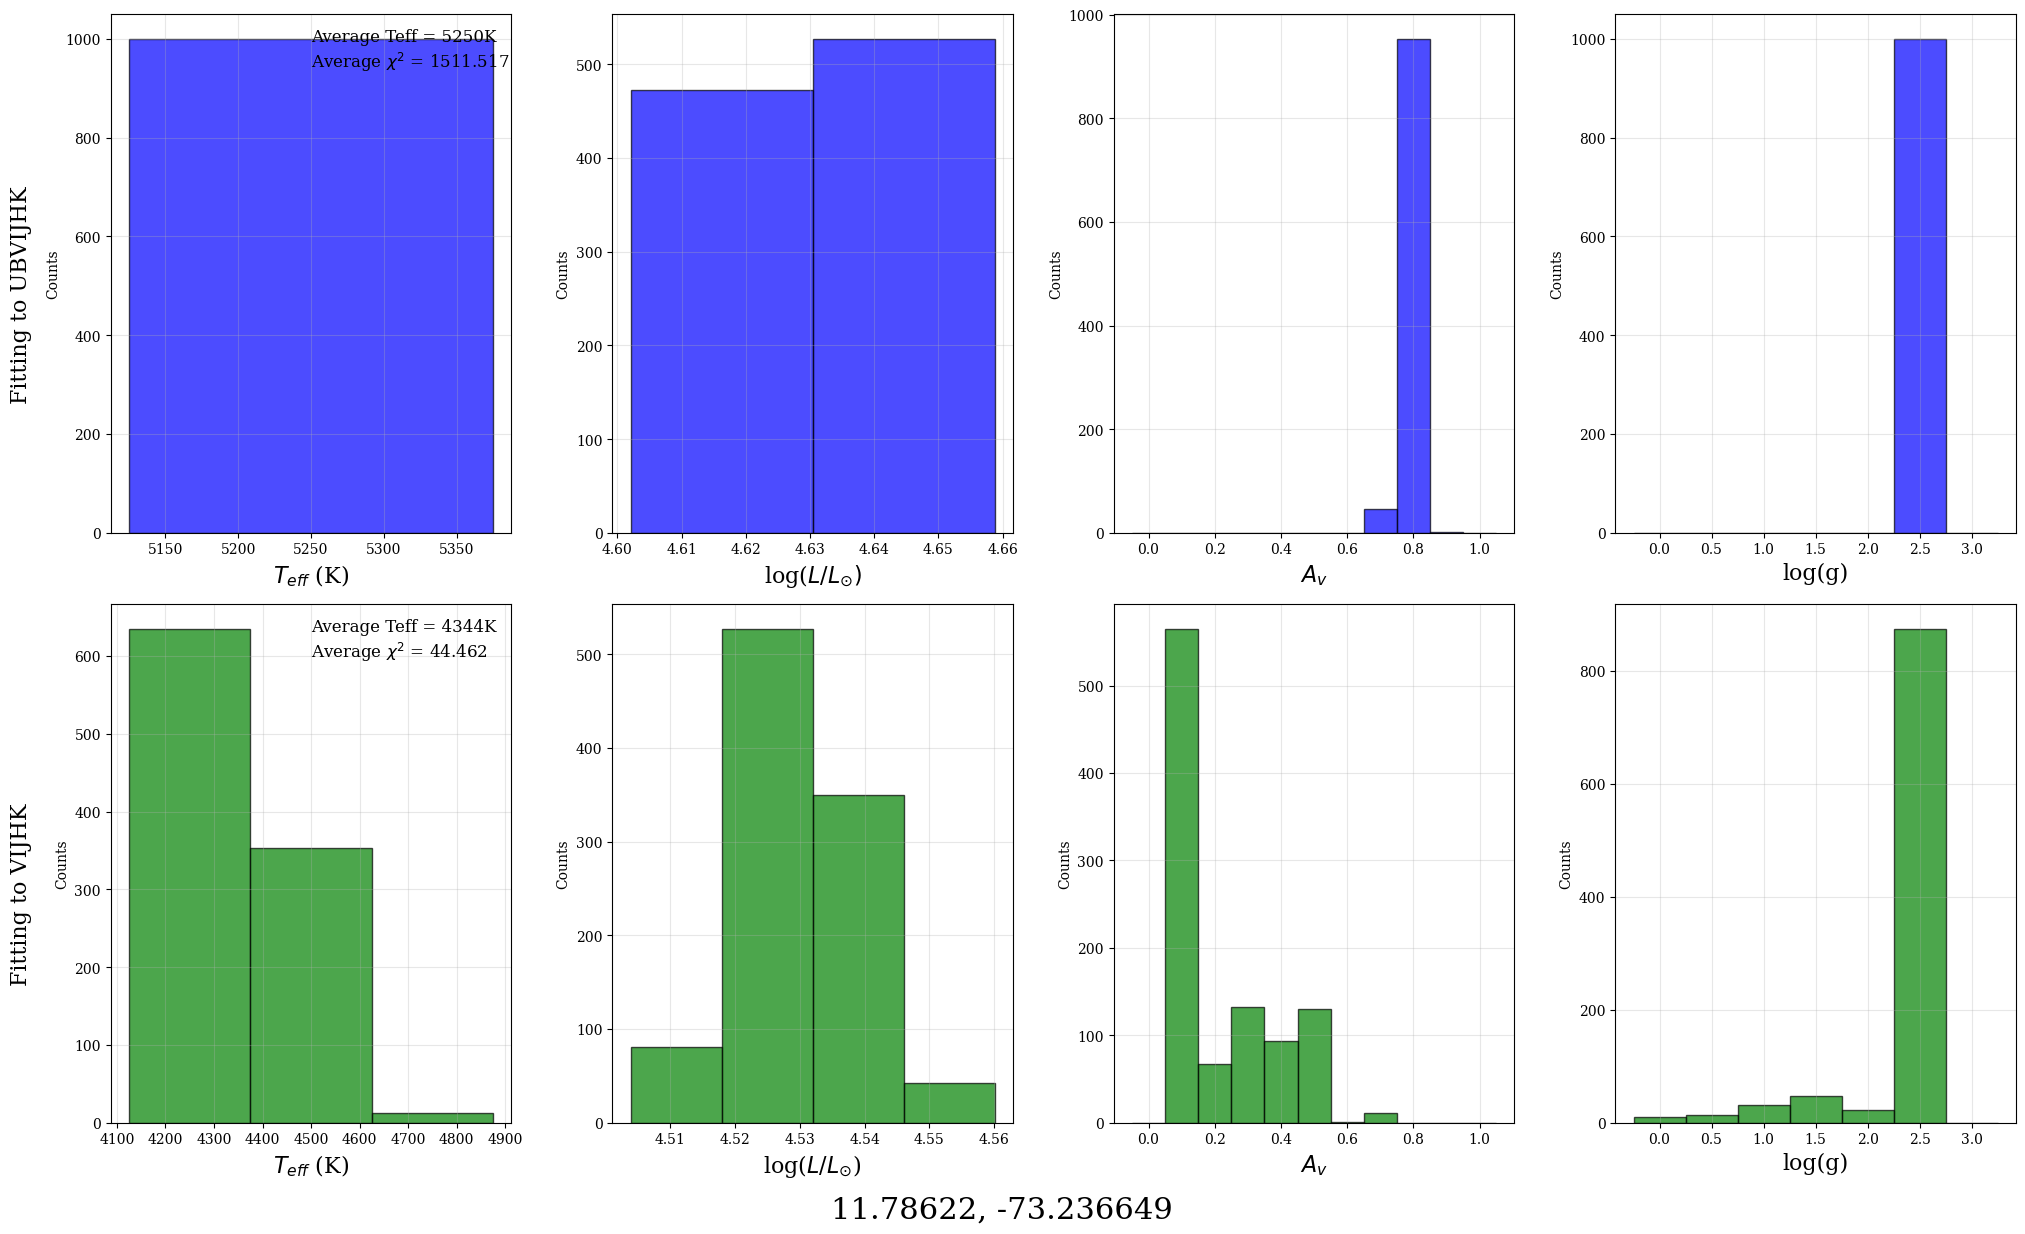

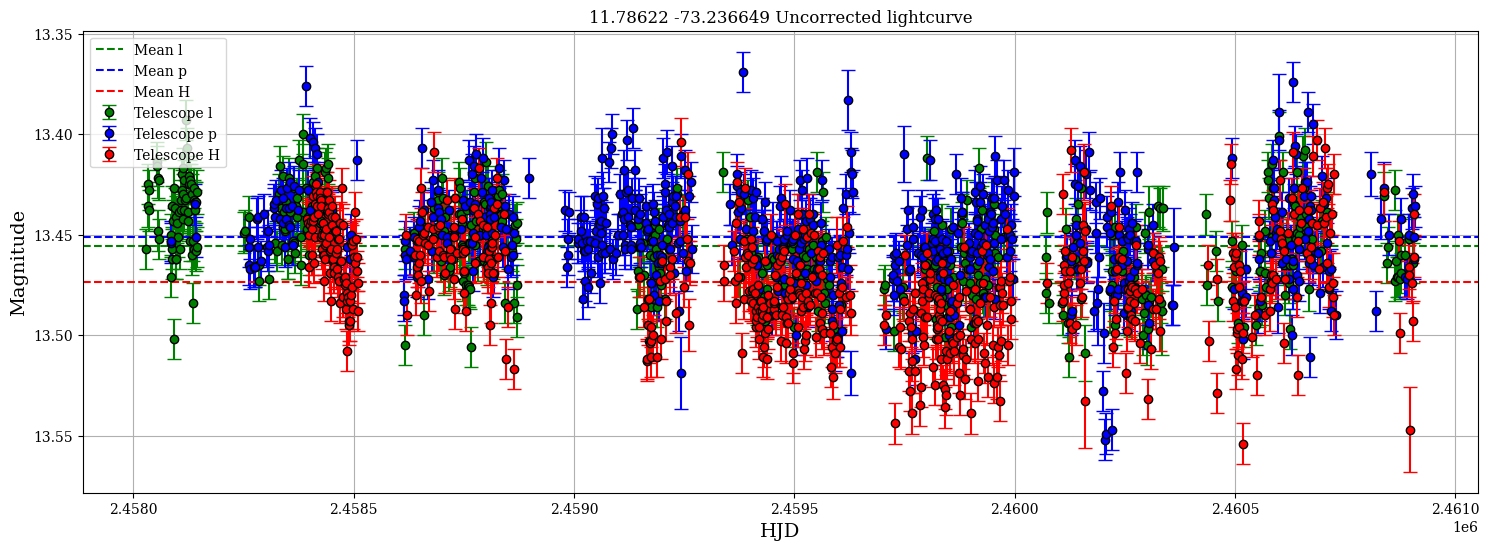

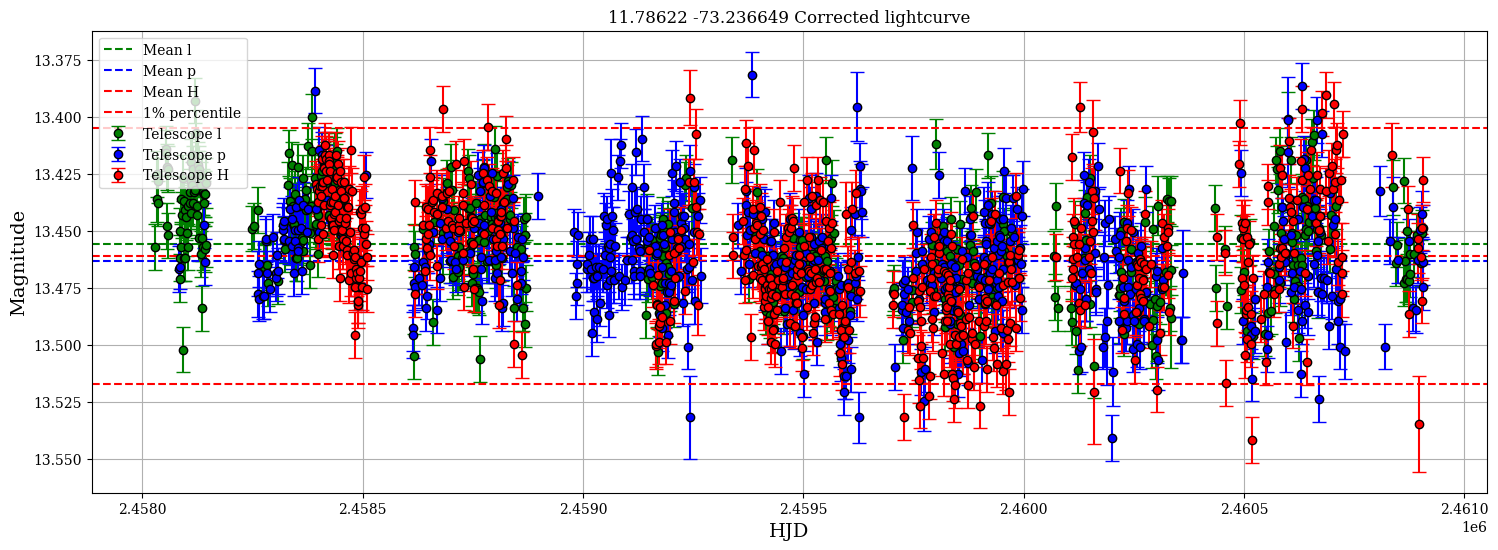

Best frequency: 0.003075 1/day, Best period: 325.24 days, Max power: 0.130, False alarm probability: 2.764e-48
False alarm level for 1.0%: 1.644e-02
Grid sampled at 15495 points


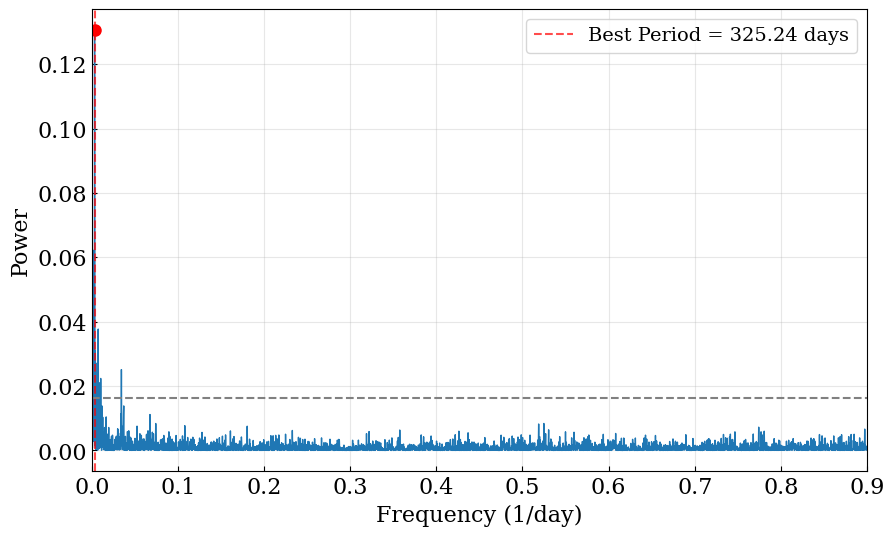

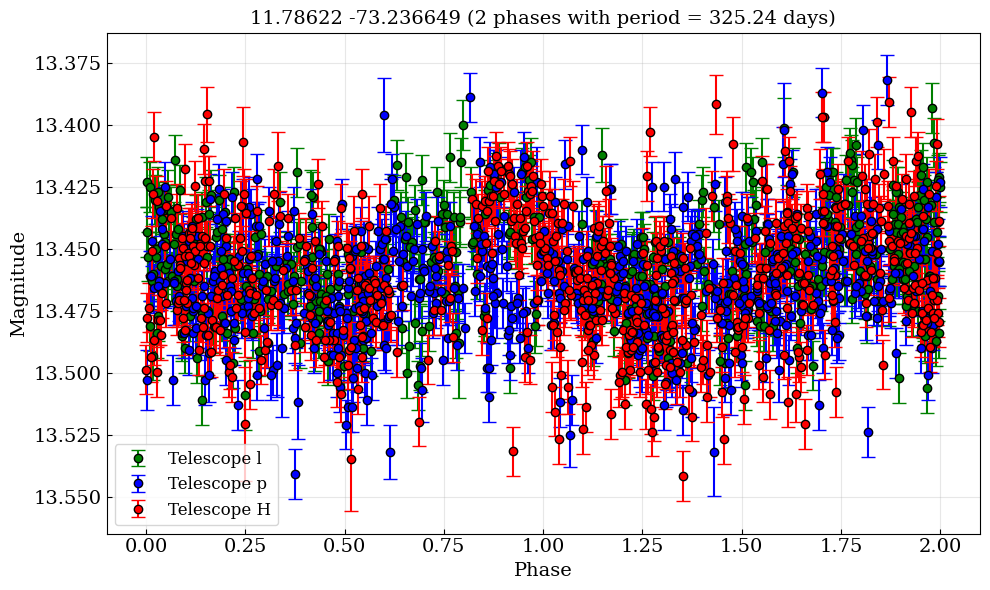

Average scatter (amplitude) per 10 point phase bin: 0.902 mJy


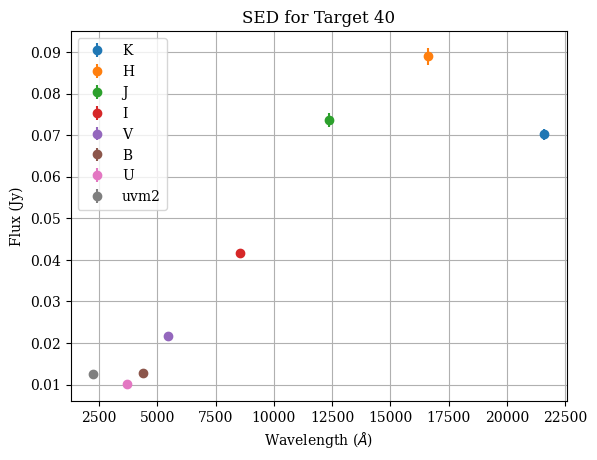

[0.00092714 0.00168169 0.00249428 0.0030747  0.00394533 0.00731178
 0.00893696 0.01021388 0.03424333]
Amplitude metrics:
	Lower 5% percentile: -0.52 mJy, 13.42 mags
	Upper 5% percentile: 0.55 mJy, 13.50 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 5% of data) (g-band: True): 1.07 mJy, 0.08 mags
Amplitude metrics:
	Lower 1% percentile: -0.75 mJy, 13.41 mags
	Upper 1% percentile: 0.79 mJy, 13.52 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 1% of data) (g-band: True): 1.55 mJy, 0.11 mags
	Largest amplitude of variability (g-band: True): 2.21 mJy, 0.16 mags
	Average amplitude across all periods: 1.740 mJy
	Standard deviation of amplitudes: 0.297 mJy
	Average amplitude (1.740 mJy) is greater than 5 sigma (0.297 mJy). This indicates consistent variability across periods.


In [11]:
star_idx = 40 #647 #384, 418
fit_models_to_star_flux(star_idx) #522, 417, 514, 51, 220, 283, 170, 429, 748, 675, 496
# print the number of excluded points for this star
print(f"Number of excluded points for star {star_idx} in V-redder: {temp_stats['total_exclusions_B_redder'].iloc[star_idx]}, most common band excluded: {temp_stats['most_common_excluded_overall'][star_idx]}")

# comment this out if you didn't downloaded the YSG lightcurves from Ben!
if star_idx < 848:
    histo(star_idx)
    info(star_idx)

In [12]:
# Debug: Check what observed_sed_allphot returns for star 647
star_idx = 647
obs = observed_sed_allphot(star_idx, coords, df_smc, df_lmc, choose_phot, flux=True, show=False)
obs_wavelengths, obs_fluxes, obs_flux_errors, obs_mags, obs_mag_errors, obs_band_names = obs

print(f"Bands returned by observed_sed_allphot for star {star_idx}:")
for i, band in enumerate(obs_band_names):
    print(f"  {band}: wavelength={obs_wavelengths[i]:.2f}, flux={obs_fluxes[i]:.3e}, mag={obs_mags[i]:.3f}")

Bands returned by observed_sed_allphot for star 647:
  Kmag_2MASS: wavelength=21590.00, flux=5.272e-16, mag=12.248
  Hmag_2MASS: wavelength=16620.00, flux=1.354e-15, mag=12.285
  Jmag_2MASS: wavelength=12350.00, flux=3.312e-15, mag=12.414
  Imag_MCPS: wavelength=8568.89, flux=1.828e-14, mag=11.759
  imag_APASS: wavelength=7457.89, flux=1.158e-14, mag=13.060
  rmag_APASS: wavelength=6141.12, flux=1.793e-14, mag=13.005
  Vmag_APASS: wavelength=5467.57, flux=2.369e-14, mag=12.965
  Vmag_MCPS: wavelength=5438.23, flux=2.526e-14, mag=12.897
  gmag_APASS: wavelength=4671.78, flux=3.097e-14, mag=13.003
  Bmag_MCPS: wavelength=4394.48, flux=3.708e-14, mag=13.060
  Bmag_APASS: wavelength=4369.53, flux=3.672e-14, mag=13.157
  Umag_MCPS: wavelength=3706.29, flux=1.609e-14, mag=13.512


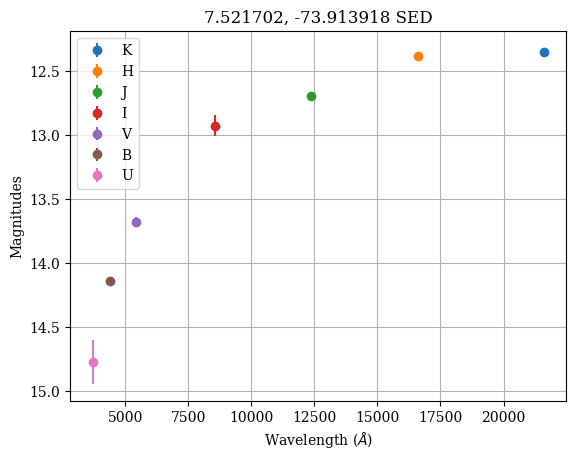

(array([21590.  , 16620.  , 12350.  ,  8568.89,  5438.23,  4394.48,
         3706.29]),
 array([4.80369298e-16, 1.23359702e-15, 2.55896681e-15, 6.23315469e-15,
        1.22788433e-14, 1.36506000e-14, 5.03785981e-15]),
 array([1.32726037e-17, 3.40842856e-17, 7.07042528e-17, 4.70740308e-16,
        4.07117328e-16, 3.77166077e-16, 8.02697317e-16]),
 array([12.349, 12.386, 12.694, 12.927, 13.68 , 14.145, 14.773]),
 array([0.03 , 0.03 , 0.03 , 0.082, 0.036, 0.03 , 0.173]),
 array(['K', 'H', 'J', 'I', 'V', 'B', 'U'], dtype='<U1'))

In [13]:
observed_sed(0, flux=False, show=True)

In [14]:
B_counter = 0
V_counter = 0
U_counter = 0

for i in range(0,848):
    if temp_stats['use_B'].iloc[i] == True:
        B_counter += 1
    elif temp_stats['use_V'].iloc[i] == True:
        V_counter += 1
    elif temp_stats['use_U'].iloc[i] == True:
        U_counter += 1

print(f"Number of stars best fit by B-redder: {B_counter}")
print(f"Number of stars best fit by V-redder: {V_counter}")
print(f"Number of stars best fit by U-redder: {U_counter}")

Number of stars best fit by B-redder: 653
Number of stars best fit by V-redder: 132
Number of stars best fit by U-redder: 63


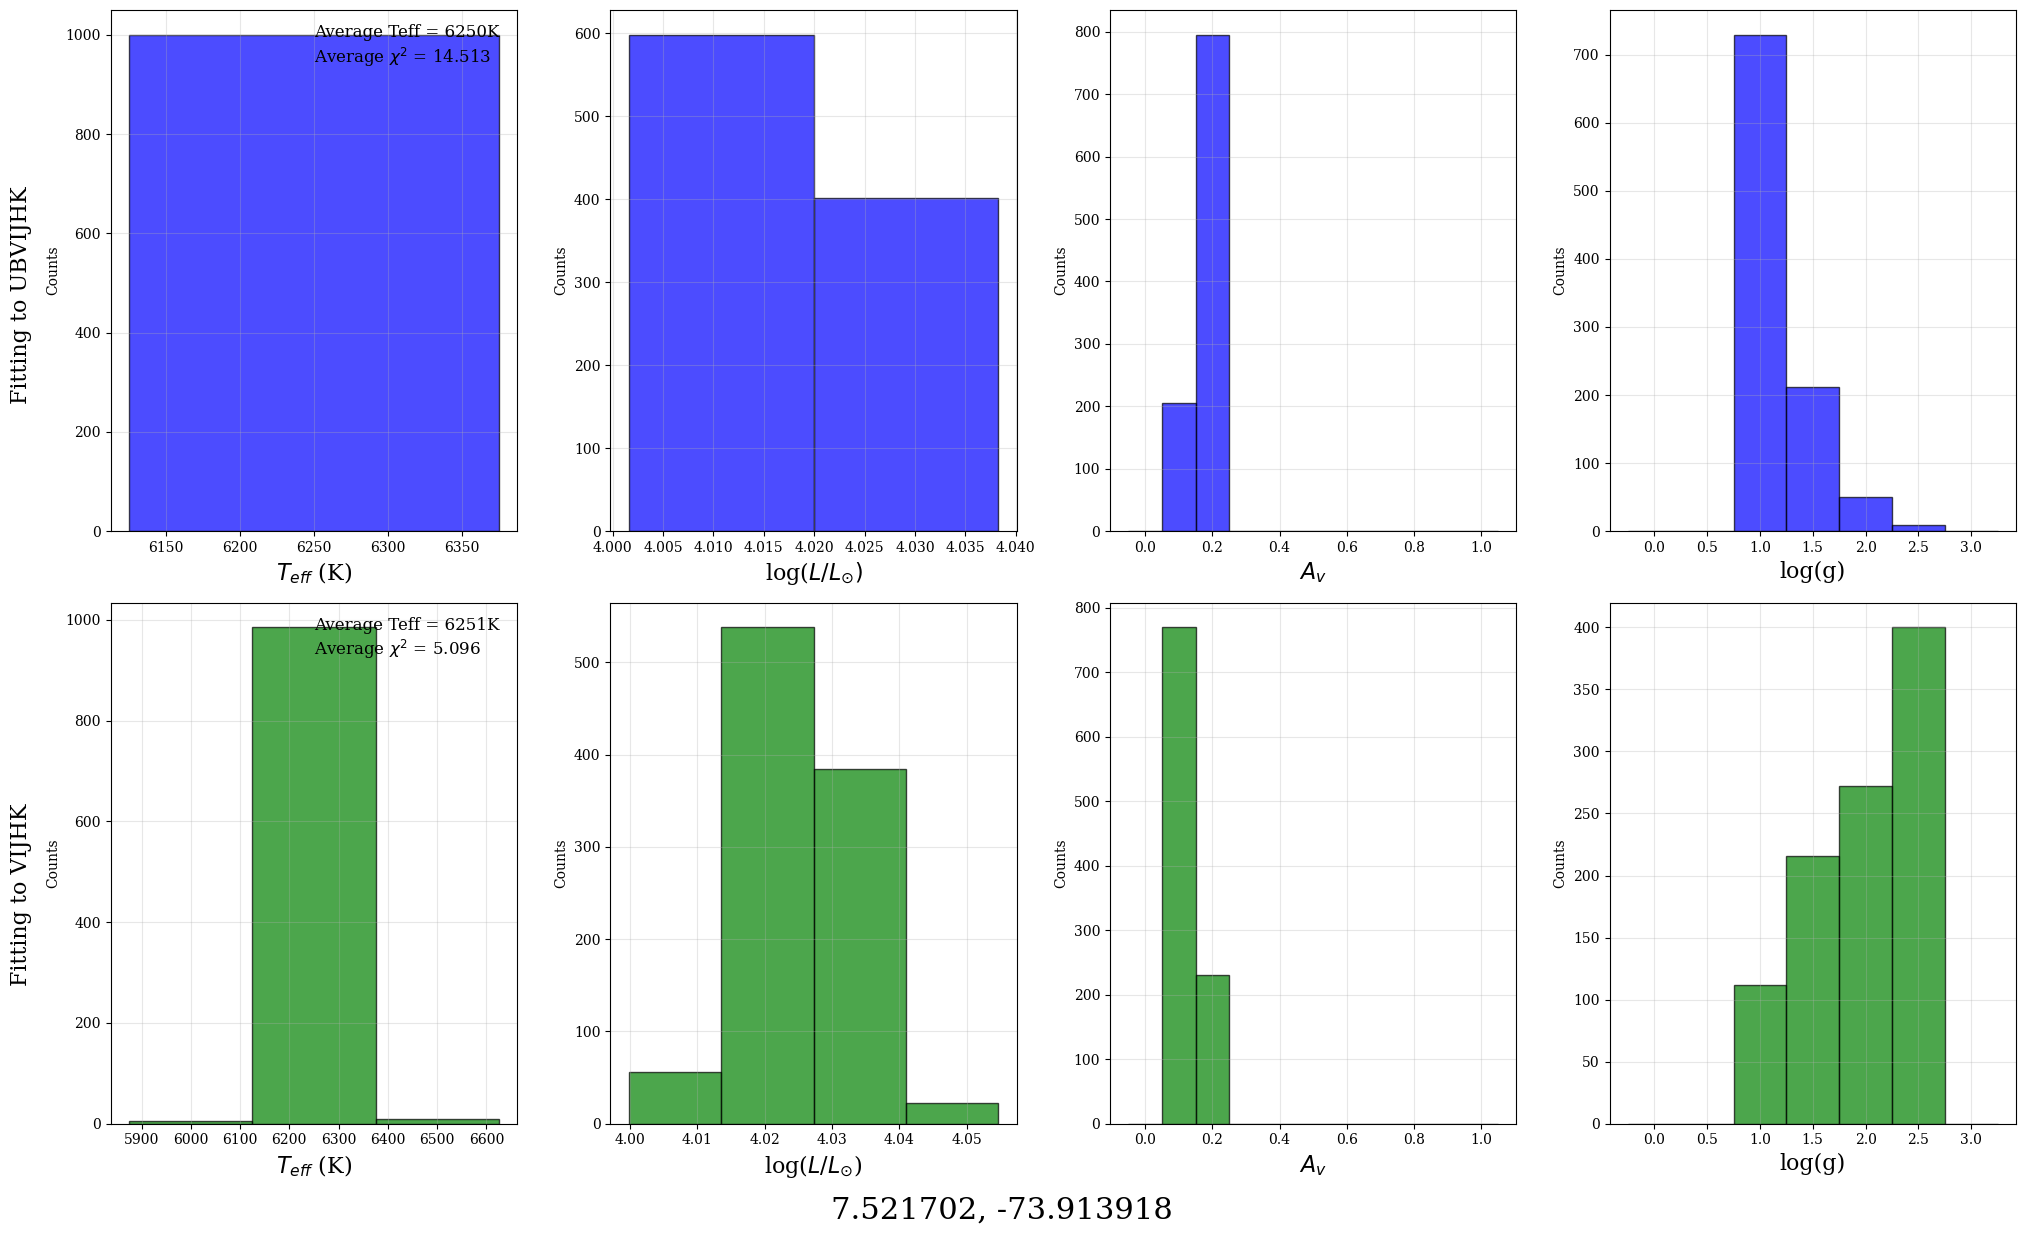

In [11]:
def histo(index):
    RA = coords['RA'].iloc[index]
    dec = coords['DEC'].iloc[index]
    binwidth = 250
    final_teff_U_redder = temp_stats['teff_mean_U_redder'].iloc[index]
    final_teff_V_redder = temp_stats['teff_mean_V_redder'].iloc[index]
    output_filename_U_redder = f'temp_fitting/{RA}_{dec}_U_redder.parquet'
    output_filename_V_redder = f'temp_fitting/{RA}_{dec}_V_redder.parquet'
    # read parquet file:
    model_fitting_U_redder = pd.read_parquet(output_filename_U_redder)
    model_fitting_V_redder = pd.read_parquet(output_filename_V_redder)
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    
    # Create bins that properly include the max value
    bins_U_redder = range(min(model_fitting_U_redder['teff']) - (binwidth//2), 
                      max(model_fitting_U_redder['teff']) + binwidth//2 + 1, binwidth)
    bins_V_redder = range(min(model_fitting_V_redder['teff']) - binwidth//2, 
                     max(model_fitting_V_redder['teff']) + binwidth//2 + 1, binwidth)
    bins_U_redder_logg = int((max(model_fitting_U_redder['logg']) - min(model_fitting_U_redder['logg'])) * 2.0)
    bins_V_redder_logg = int((max(model_fitting_V_redder['logg']) - min(model_fitting_V_redder['logg'])) * 2.0)
    # Ensure minimum number of bins
    bins_U_redder_logg = max(bins_U_redder_logg, 1)
    bins_V_redder_logg = max(bins_V_redder_logg, 1)  
    
    # Top row - 'full' plots in blue
    axes[0, 0].hist(model_fitting_U_redder['teff'], bins=bins_U_redder, color='blue', alpha=0.7, edgecolor='black')
    axes[0, 0].annotate(f'Average Teff = {final_teff_U_redder:.0f}K \nAverage $\\chi^2$ = {temp_stats.loc[index, "chi2_U_redder_mean"]:.3f}', xy=(0.5, 0.9), xycoords='axes fraction', fontsize=12)
    axes[0, 0].set_xlabel('$T_{eff}$ (K)', fontsize=16)
    axes[0, 0].set_ylabel('Counts')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].hist(model_fitting_U_redder['logL'], bins=len(bins_U_redder), color='blue', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('log($L/L_{\\odot})$', fontsize=16)
    axes[0, 1].set_ylabel('Counts')
    axes[0, 1].grid(True, alpha=0.3)

    # Define custom bin edges for A_v and log(g)
    av_bins = np.arange(-0.05, 1.15, 0.1)  # Centers on 0, 0.1, 0.2, ..., 1.0
    logg_bins = np.arange(-0.25, 3.75, 0.5)  # Centers on 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0

    axes[0, 2].hist(model_fitting_U_redder['av'], bins=av_bins, color='blue', alpha=0.7, edgecolor='black')
    axes[0, 2].set_xlabel('$A_v$', fontsize=16)
    axes[0, 2].set_ylabel('Counts')
    axes[0, 2].grid(True, alpha=0.3)

    axes[0, 3].hist(model_fitting_U_redder['logg'], bins=logg_bins, color='blue', alpha=0.7, edgecolor='black')
    axes[0, 3].set_xlabel('log(g)', fontsize=16)
    axes[0, 3].set_ylabel('Counts')
    axes[0, 3].grid(True, alpha=0.3)
    
    # Bottom row - 'cut' plots in green
    axes[1, 0].hist(model_fitting_V_redder['teff'], bins=bins_V_redder, color='green', alpha=0.7, edgecolor='black')
    axes[1, 0].annotate(f'Average Teff = {final_teff_V_redder:.0f}K \nAverage $\\chi^2$ = {temp_stats.loc[index, "chi2_V_redder_mean"]:.3f}', xy=(0.5, 0.9), xycoords='axes fraction', fontsize=12)
    axes[1, 0].set_xlabel('$T_{eff}$ (K)', fontsize=16)
    axes[1, 0].set_ylabel('Counts')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].hist(model_fitting_V_redder['logL'], bins=len(bins_V_redder), color='green', alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('log($L/L_{\\odot}$)', fontsize=16)
    axes[1, 1].set_ylabel('Counts')
    axes[1, 1].grid(True, alpha=0.3)

    axes[1, 2].hist(model_fitting_V_redder['av'], bins=av_bins, color='green', alpha=0.7, edgecolor='black')
    axes[1, 2].set_xlabel('$A_v$', fontsize=16)
    axes[1, 2].set_ylabel('Counts')
    axes[1, 2].grid(True, alpha=0.3)

    axes[1, 3].hist(model_fitting_V_redder['logg'], bins=logg_bins, color='green', alpha=0.7, edgecolor='black')
    axes[1, 3].set_xlabel('log(g)', fontsize=16)
    axes[1, 3].set_ylabel('Counts')
    axes[1, 3].grid(True, alpha=0.3)
    
    # Add row labels
    fig.text(-0.005, 0.75, 'Fitting to UBVIJHK', rotation=90, fontsize=16, va='center', ha='center')
    fig.text(-0.005, 0.25, 'Fitting to VIJHK', rotation=90, fontsize=16, va='center', ha='center')
    fig.text(0.4,-0.02, f'{RA}, {dec}', fontsize=22)
    
    plt.tight_layout()
    plt.show()

# comment this in if you downloaded the parquet files!
histo(0)

# Just looking at model spectra (checking for differences between different atmosphere models):

KeyError: 'Jmag_2MASS'

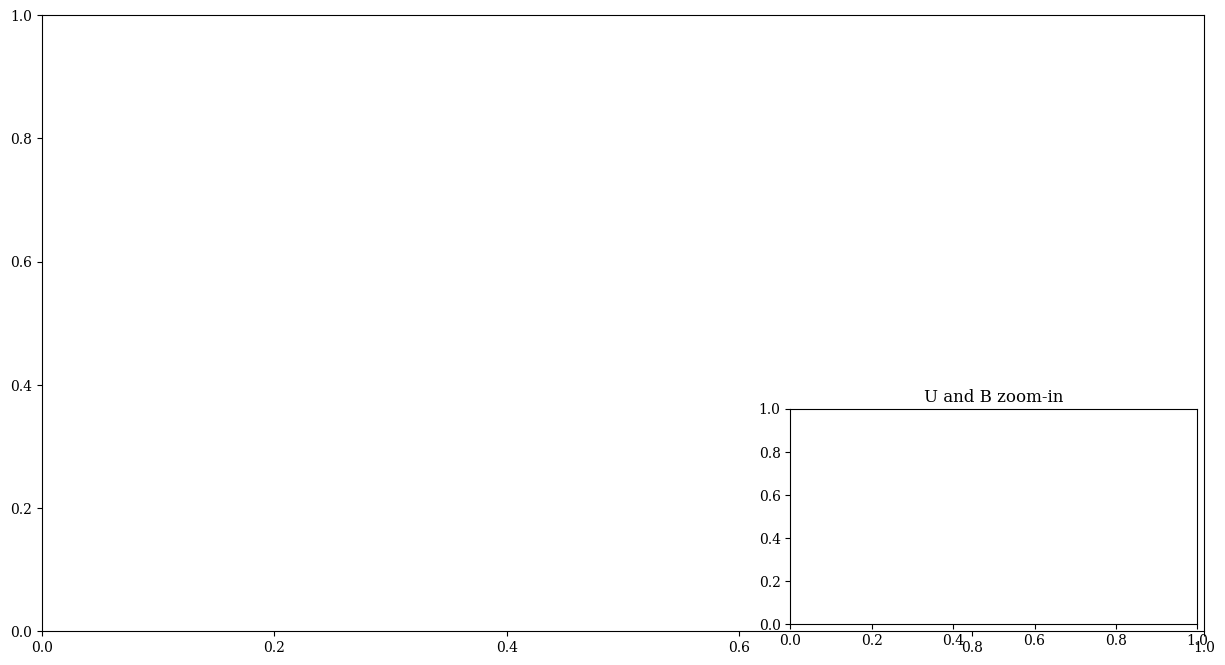

In [12]:
filenames_to_test = [
#     './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t6000_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
#     './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t7000_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    # './pysynphot_data/grid/bosz/r2000/m-0.75/bosz2024_ms_t7500_g+2.0_m-0.75_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    # './pysynphot_data/grid/bosz/r2000/m-0.75/bosz2024_ap_t7500_g+2.0_m-0.75_a+0.00_c+0.00_v2_r2000_resam.txt.gz']
    # './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t8000_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    # './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t8000_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz']
    # './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t9000_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    # './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t10000_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',


    './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t11250_g+3.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t11500_g+3.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t11750_g+3.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t12000_g+3.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',    
    './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t12500_g+3.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t13000_g+3.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t13500_g+3.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz']
# Define the correct order and names to match compute_synth_photometry output
synth_band_names = ['Jmag_2MASS', 'Hmag_2MASS', 'Kmag_2MASS', 'Umag_MCPS', 'Bmag_MCPS', 'Vmag_MCPS', 'Imag_MCPS', 'uvm2mag_SWIFT', 'uvw1mag_SWIFT', 'uvw2mag_SWIFT']
synth_wavelengths = [band_wavelengths[band] for band in synth_band_names]

fig, ax = plt.subplots(figsize=(15, 8))
# inset axes in the lower right corner
axins = inset_axes(ax, width="35%", height="35%", loc='lower right')
axins.set_title('U and B zoom-in', fontsize=12, pad=5) 
colors = plt.cm.viridis(np.linspace(0, 1, len(filenames_to_test)))

# Store first model's magnitudes for band labeling
first_model_mags = None
first_model_flux = None

for i, model in enumerate(filenames_to_test):
    data = np.loadtxt(model)
    # Create a dictionary-like structure that the function expects
    flux_data = {'flux': data[:,0]}
    synth_phot = compute_synth_photometry(wave, flux_data) 
    points_mag = [synth_phot[band]['mag'] for band in synth_band_names]
    points_flux = [synth_phot[band]['flux'] for band in synth_band_names]
    
    # Store first model's magnitudes for consistent band labeling
    if i == 0:
        first_model_mags = points_mag
        first_model_flux = points_flux
    
    # Parse model parameters from filename for label
    import re
    match = re.search(r't(\d+)_g([+-]?\d+\.?\d*)', os.path.basename(model))
    if match:
        teff = match.group(1)
        logg = match.group(2)
        atmosphere_type = 'ms' if 'ms' in os.path.basename(model) else 'ap'
        model_label = f'T={teff}K, log(g)={logg}, type={atmosphere_type}'
    else:
        model_label = os.path.basename(model)
    if teff == '12000':
        ax.plot(synth_wavelengths, points_flux, 'o', color='red', 
            label=model_label, markersize=8, linewidth=2, zorder = 10)
        ax.plot(wave['wave'], flux_data['flux'], color='red', alpha=0.5)
        axins.plot(wave['wave'], flux_data['flux'], color='red', alpha=0.5, zorder=10)
        axins.plot(synth_wavelengths, points_flux, 'o', color='red', 
                label=model_label, markersize=8, linewidth=2, zorder = 11)
    else:
        ax.plot(wave['wave'], flux_data['flux'], color=colors[i], alpha=0.5)
        ax.plot(synth_wavelengths, points_flux, 'o', color=colors[i], 
                label=model_label, markersize=8, linewidth=2, zorder = 10)
        # Plot the zoom to U and B band region
        axins.plot(wave['wave'], flux_data['flux'], color=colors[i], alpha=0.5, zorder=10)
        axins.plot(synth_wavelengths, points_flux, 'o', color=colors[i], 
                label=model_label, markersize=8, linewidth=2, zorder = 11)
    # Add band name labels only once, using the first model's positions
for j, (wl, mag, band) in enumerate(zip(synth_wavelengths, first_model_mags, synth_band_names)):
    ax.annotate(band, (wl, mag), xytext=(20, 5), textcoords='offset points', 
               fontsize=10, ha='center', fontweight='bold')
for j, (wl, mag, band) in enumerate(zip(synth_wavelengths, first_model_flux, synth_band_names)):
    ax.annotate(band, (wl, mag), xytext=(0, -25), textcoords='offset points', 
               fontsize=10, ha='center', fontweight='bold')

# # Set zoom limits around U band
# axins.set_xlim(3500, 4800)
# axins.set_ylim(1e6, 4e7)  # Set appropriate flux range 


# ax.set_xlabel('Wavelength ($\\AA$)', fontsize=14)
# # ax.set_ylabel('Magnitude', fontsize=14)
# ax.set_ylabel('Flux ($erg/s/cm^2/\\AA$)')
# # ax.set_xlim(0,40000)
# ax.set_ylim(1e4,1e8)
# ax.set_yscale('log')
# ax.set_xscale('log')
# # ax.set_title('Synthetic Photometry - BOSZ Models (T=4000K, varying log(g))', fontsize=16)
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [ ]:
# comparing similar models but ap and ms atmospheres:
ms = './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t8000_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz'
ap = './pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ap_t8000_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz'


# Overall properties of YSGs from SED fitting results:

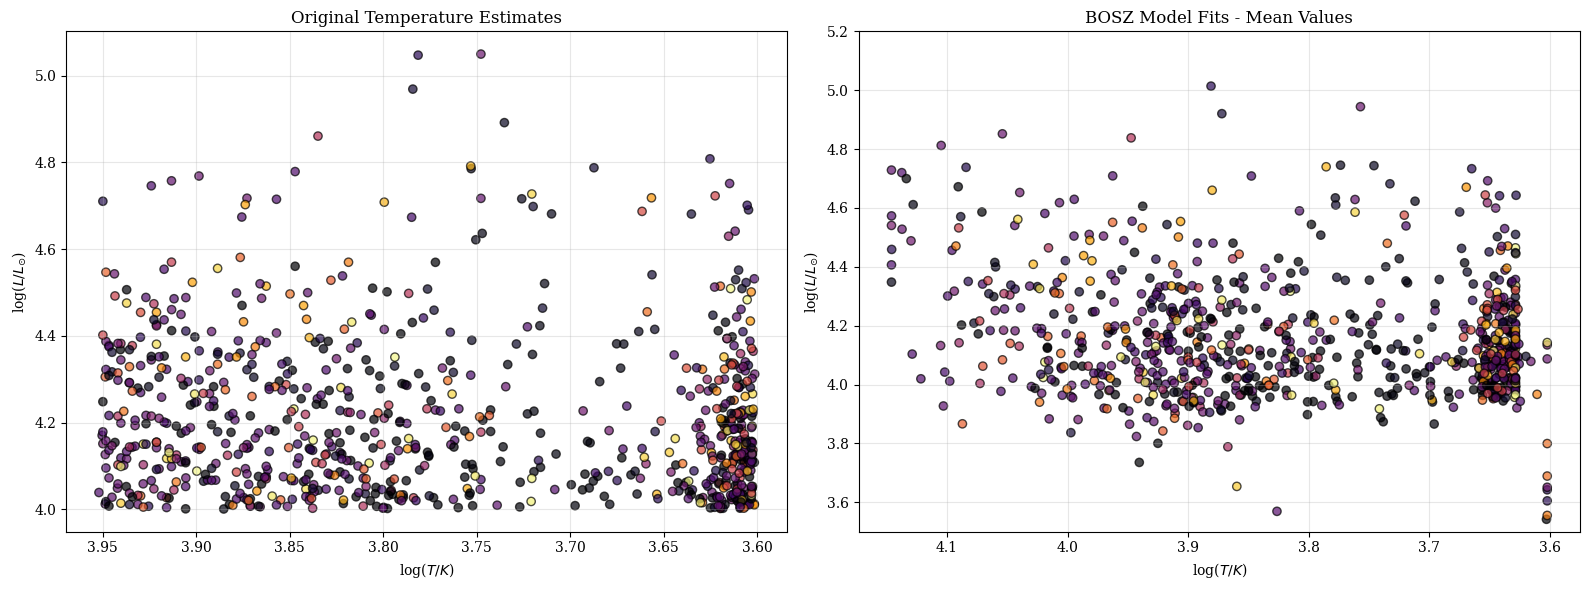

In [13]:
def HR_comparison(V_redder=True):
    if V_redder ==True: # show results from fitting to V-redder bands
        logT = temp_stats['logT_mean_V_redder']
        logL = temp_stats['logL_mean_V_redder']
    else: # show results from fitting to U_redder bands
        logT = temp_stats['logT_mean_U_redder']
        logL = temp_stats['logL_mean_U_redder'] 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Old estimations
    periods = stats['best_period']
    x_old = stats['logT']
    y_old = stats['logL']
    sc1 = ax1.scatter(x_old, y_old, c=periods, edgecolor='k', label='old estimations', alpha=0.7, cmap='inferno')
    ax1.set_xlabel('log($T/K$)')
    ax1.set_ylabel('log($L/L_{\\odot}$)')
    ax1.set_title('Original Temperature Estimates')
    ax1.invert_xaxis()
    ax1.grid(True, alpha=0.3)

    sc = ax2.scatter(logT[:848], logL[:848], c= periods, edgecolor='k', label='new estimations', alpha=0.7, cmap='inferno')
    # ax2.plot([3.95, 3.60], [4.0, 4.0], linestyle = 'dashed', color='darkgrey')
    ax2.set_xlabel('log($T/K$)')
    ax2.set_ylabel('log($L/L_{\\odot}$)')
    ax2.set_title('BOSZ Model Fits - Mean Values')
    ax2.set_ylim(3.5, 5.2)
    ax2.invert_xaxis()
    ax2.grid(True, alpha=0.3)
    # cbar = plt.colorbar(sc, ax=ax2)
    # cbar.set_label('Period (days)')
    plt.tight_layout()
    # plt.savefig('HR_comparison.png', bbox_inches='tight')
    plt.show()
HR_comparison()

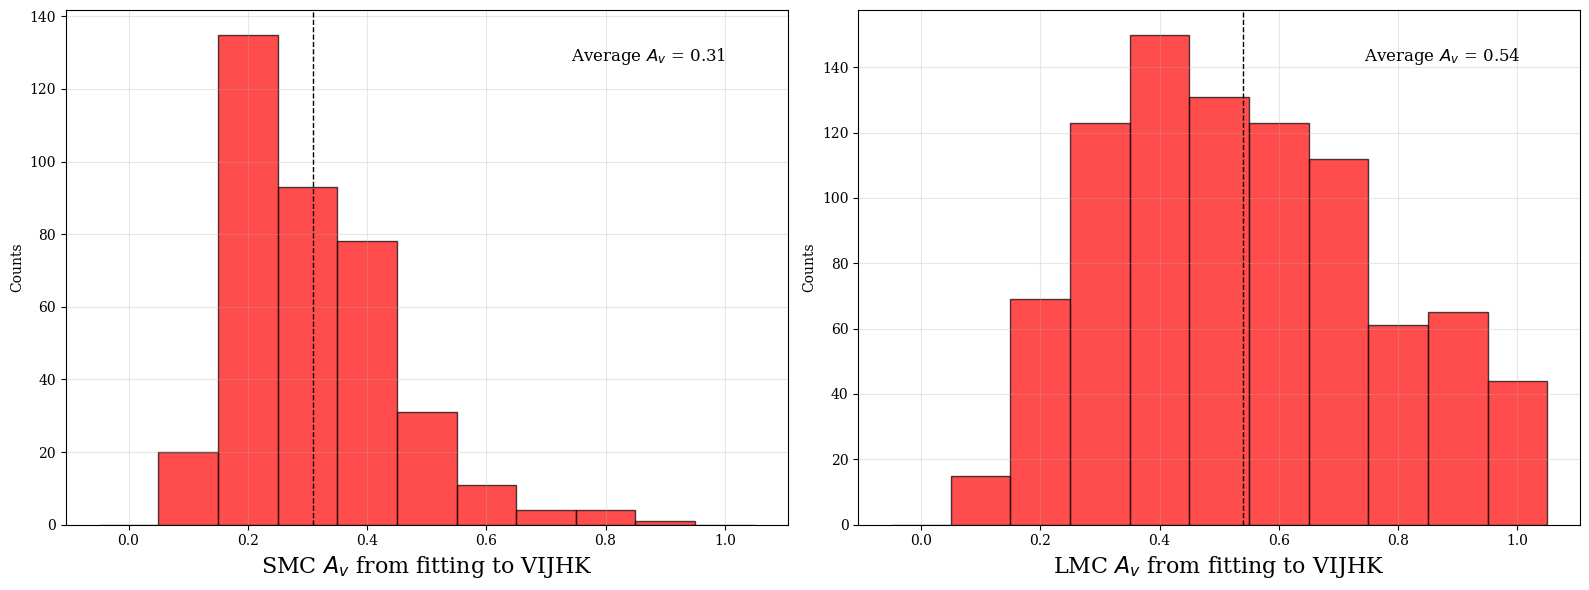

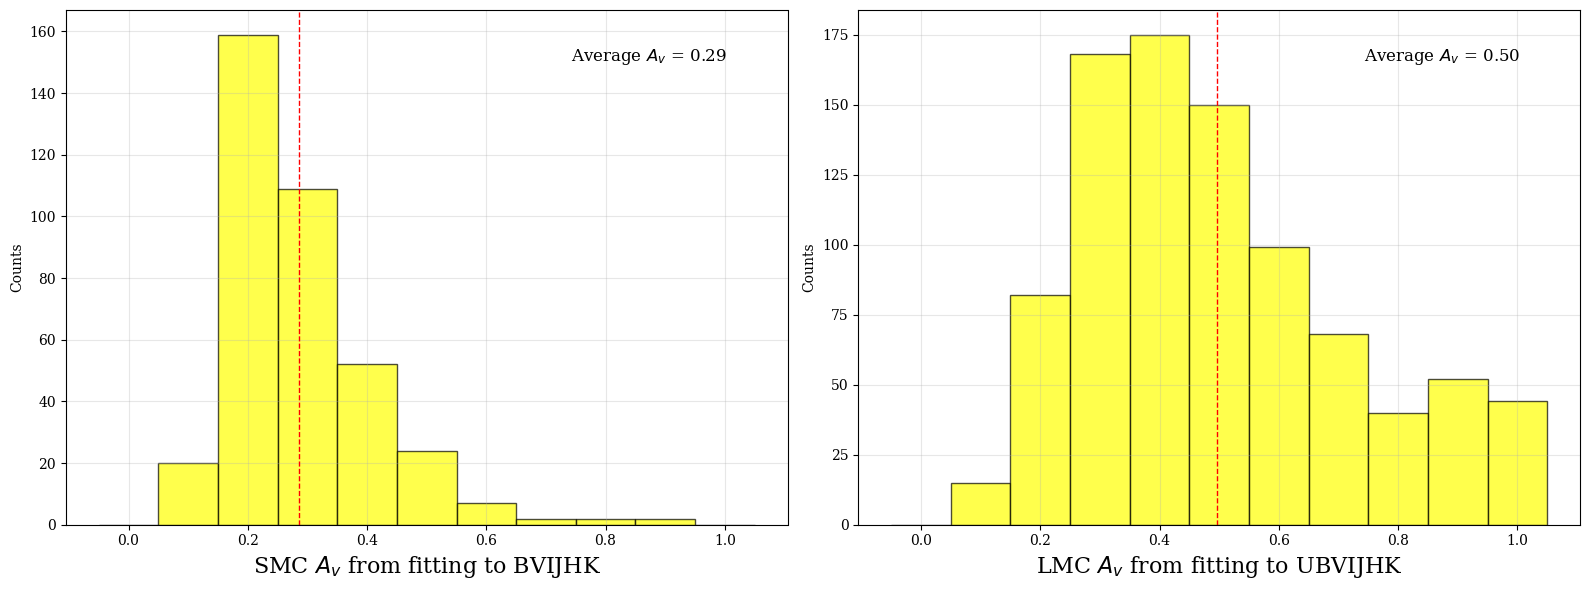

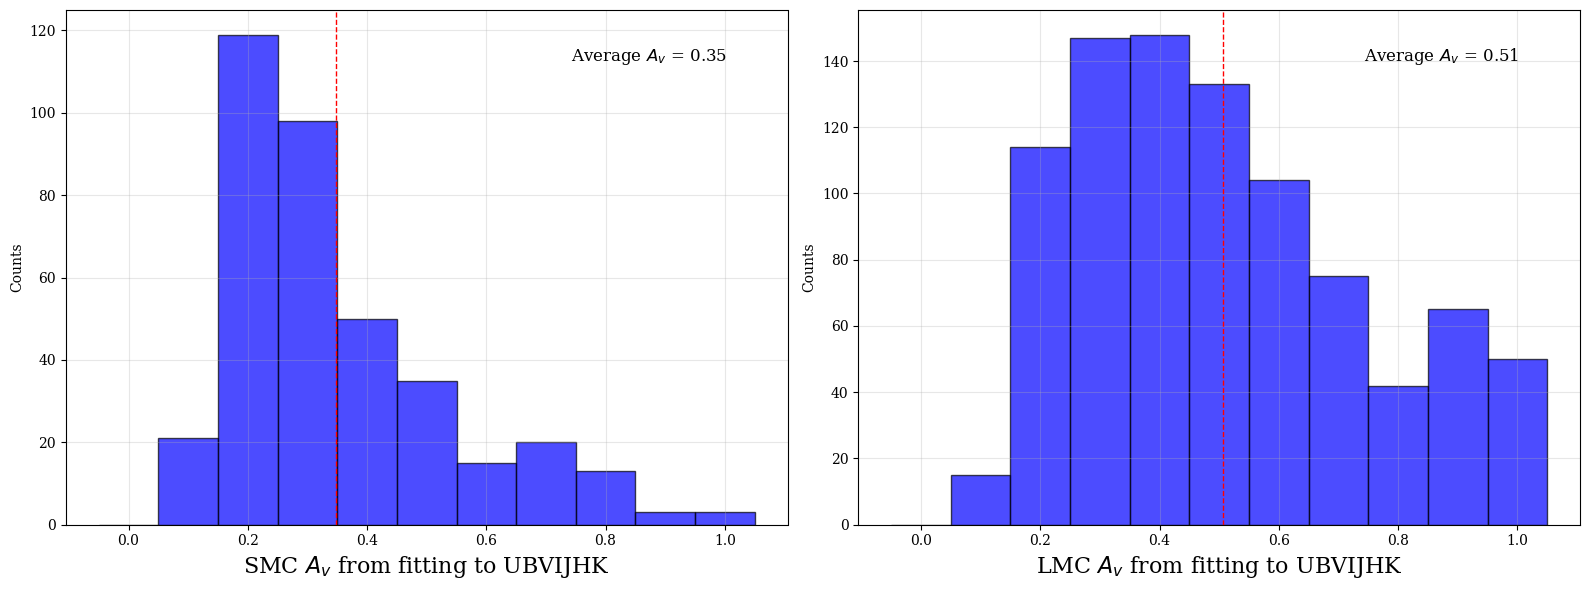

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

av_bins = np.arange(-0.05, 1.15, 0.1)
ax1.hist(temp_stats['av_mean_V_redder'][:377], bins=av_bins, color='red', alpha=0.7, edgecolor='black')
ax1.set_xlabel('SMC $A_v$ from fitting to VIJHK', fontsize=16)
average_av_smc = np.mean(temp_stats['av_mean_V_redder'][:377])
ax1.axvline(average_av_smc, color='black', linestyle='dashed', linewidth=1)
ax1.annotate(f'Average $A_v$ = {average_av_smc:.2f}', xy=(0.7, 0.9), xycoords='axes fraction', fontsize=12)
ax1.set_ylabel('Counts')
ax1.grid(True, alpha=0.3)

ax2.hist(temp_stats['av_mean_V_redder'][377:], bins=av_bins, color='red', alpha=0.7, edgecolor='black')
ax2.set_xlabel('LMC $A_v$ from fitting to VIJHK', fontsize=16)
average_av_lmc = np.mean(temp_stats['av_mean_V_redder'][377:])
ax2.axvline(average_av_lmc, color='black', linestyle='dashed', linewidth=1)
ax2.annotate(f'Average $A_v$ = {average_av_lmc:.2f}', xy=(0.7, 0.9), xycoords='axes fraction', fontsize=12)
ax2.set_ylabel('Counts')
ax2.grid(True, alpha=0.3)
# fig.text(0.5,-0.02, 'LMC', fontsize=22)

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

av_bins = np.arange(-0.05, 1.15, 0.1)
ax1.hist(temp_stats['av_mean_B_redder'][:377], bins=av_bins, color='yellow', alpha=0.7, edgecolor='black')
ax1.set_xlabel('SMC $A_v$ from fitting to BVIJHK', fontsize=16)
average_av_smc = np.mean(temp_stats['av_mean_B_redder'][:377])
ax1.axvline(average_av_smc, color='red', linestyle='dashed', linewidth=1)
ax1.annotate(f'Average $A_v$ = {average_av_smc:.2f}', xy=(0.7, 0.9), xycoords='axes fraction', fontsize=12)
ax1.set_ylabel('Counts')
ax1.grid(True, alpha=0.3)

ax2.hist(temp_stats['av_mean_B_redder'][377:], bins=av_bins, color='yellow', alpha=0.7, edgecolor='black')
ax2.set_xlabel('LMC $A_v$ from fitting to UBVIJHK', fontsize=16)
average_av_lmc = np.mean(temp_stats['av_mean_B_redder'][377:])
ax2.axvline(average_av_lmc, color='red', linestyle='dashed', linewidth=1)
ax2.annotate(f'Average $A_v$ = {average_av_lmc:.2f}', xy=(0.7, 0.9), xycoords='axes fraction', fontsize=12)
ax2.set_ylabel('Counts')
ax2.grid(True, alpha=0.3)
# fig.text(0.5,-0.02, 'LMC', fontsize=22)

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

av_bins = np.arange(-0.05, 1.15, 0.1)
ax1.hist(temp_stats['av_mean_U_redder'][:377], bins=av_bins, color='blue', alpha=0.7, edgecolor='black')
ax1.set_xlabel('SMC $A_v$ from fitting to UBVIJHK', fontsize=16)
average_av_smc = np.mean(temp_stats['av_mean_U_redder'][:377])
ax1.axvline(average_av_smc, color='red', linestyle='dashed', linewidth=1)
ax1.annotate(f'Average $A_v$ = {average_av_smc:.2f}', xy=(0.7, 0.9), xycoords='axes fraction', fontsize=12)
ax1.set_ylabel('Counts')
ax1.grid(True, alpha=0.3)

ax2.hist(temp_stats['av_mean_U_redder'][377:], bins=av_bins, color='blue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('LMC $A_v$ from fitting to UBVIJHK', fontsize=16)
average_av_lmc = np.mean(temp_stats['av_mean_U_redder'][377:])
ax2.axvline(average_av_lmc, color='red', linestyle='dashed', linewidth=1)
ax2.annotate(f'Average $A_v$ = {average_av_lmc:.2f}', xy=(0.7, 0.9), xycoords='axes fraction', fontsize=12)
ax2.set_ylabel('Counts')
ax2.grid(True, alpha=0.3)
# fig.text(0.5,-0.02, 'LMC', fontsize=22)

plt.tight_layout()
plt.show()

### Comparison showing which are binary candidates:

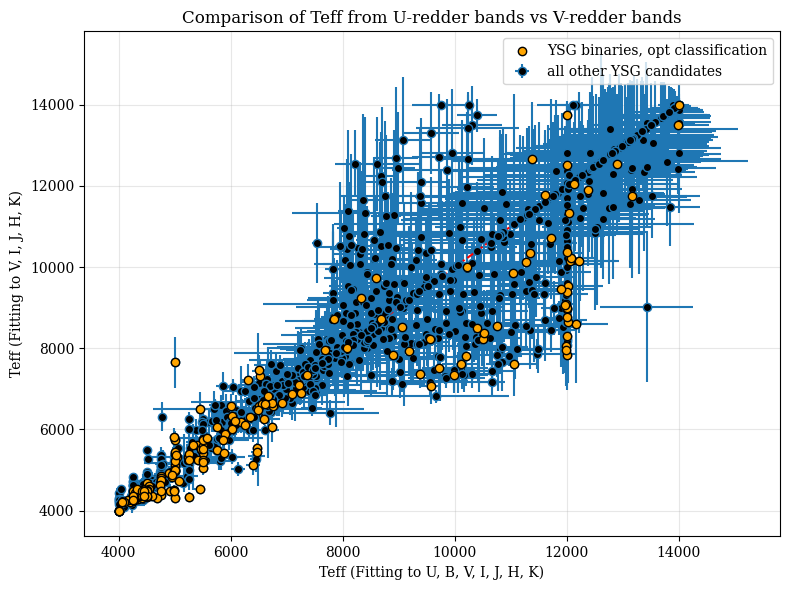

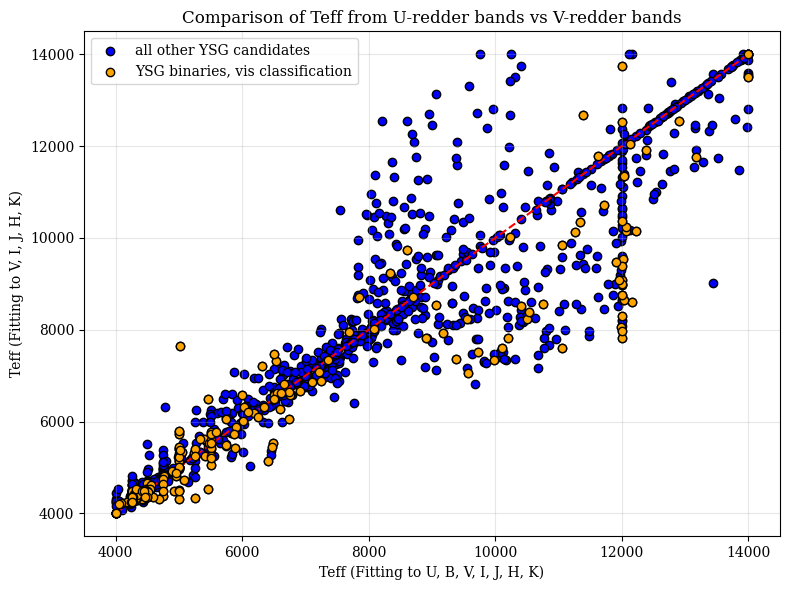

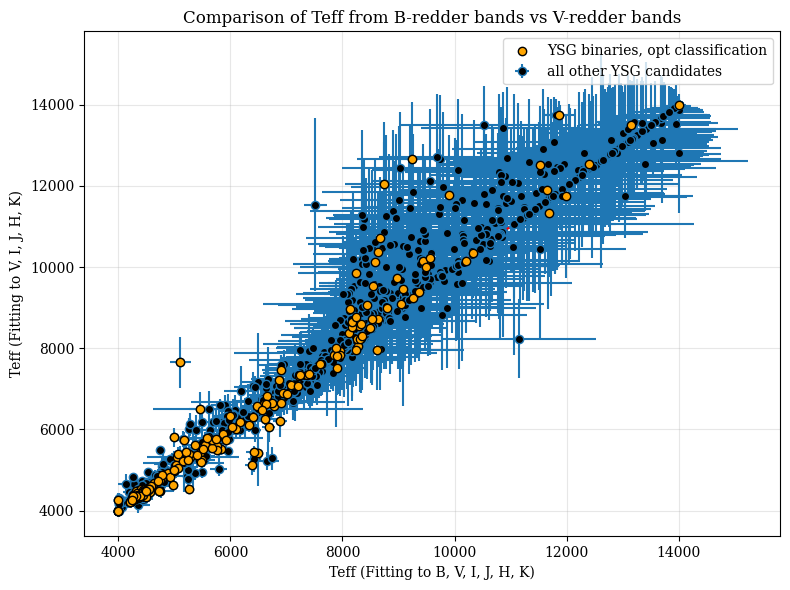

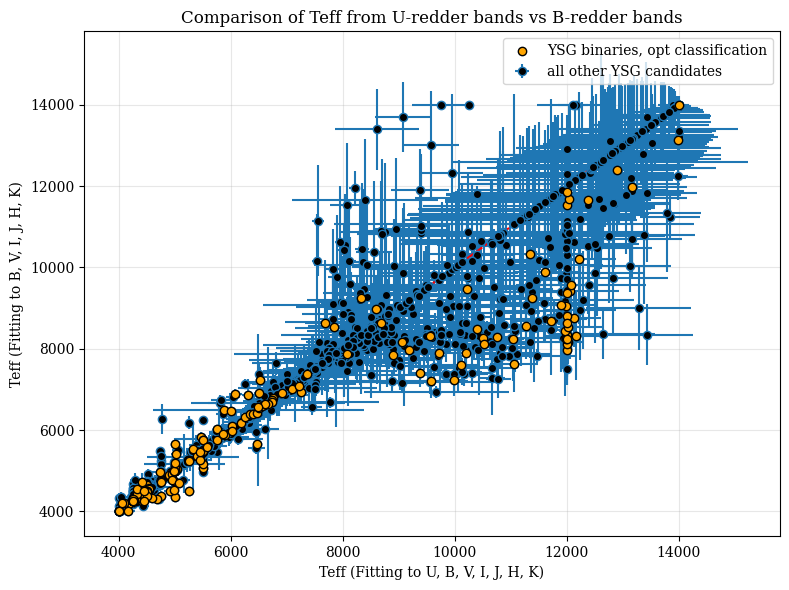

In [ ]:
teff_U_redderbands = temp_stats['teff_mean_U_redder']
teff_B_redderbands = temp_stats['teff_mean_B_redder']
teff_V_redderbands = temp_stats['teff_mean_V_redder']
teff_U_redderstd = temp_stats['teff_std_U_redder']
teff_B_redderstd = temp_stats['teff_std_B_redder']
teff_V_redderstd = temp_stats['teff_std_V_redder']
chi2_V_redder = temp_stats['chi2_V_redder_mean']
chi2_B_redder = temp_stats['chi2_B_redder_mean']
chi2_U_redder = temp_stats['chi2_U_redder_mean']
yerr_U_redder = [temp_stats['chi2_U_redder_mean'] - temp_stats['teff_16perc_U_redder'], temp_stats['teff_84perc_U_redder'] - temp_stats['teff_mean_U_redder']]
yerr_B_redder = [temp_stats['chi2_B_redder_mean'] - temp_stats['teff_16perc_B_redder'], temp_stats['teff_84perc_B_redder'] - temp_stats['teff_mean_B_redder']]
xerr_U_redder = [temp_stats['teff_mean_U_redder'] - temp_stats['teff_16perc_U_redder'], temp_stats['teff_84perc_U_redder'] - temp_stats['teff_mean_U_redder']] 
yerr_V_redder = [temp_stats['logL_mean_V_redder'] - temp_stats['logL_16perc_V_redder'],temp_stats['logL_84perc_V_redder'] - temp_stats['logL_mean_V_redder']]
yerr_B_redder = [temp_stats['logL_mean_B_redder'] - temp_stats['logL_16perc_B_redder'],temp_stats['logL_84perc_B_redder'] - temp_stats['logL_mean_B_redder']]
yerr_V_redder = [temp_stats['teff_mean_V_redder'] - temp_stats['teff_16perc_V_redder'],temp_stats['teff_84perc_V_redder'] - temp_stats['teff_mean_V_redder']]

# Binary identification from Anna 
smc_opt_bin = smc_opt_binaries
lmc_opt_bin = lmc_opt_binaries
all_opt_bin = pd.concat([smc_opt_bin, lmc_opt_bin], ignore_index=True)
smc_vis_bin = smc_vis_binaries
lmc_vis_bin = lmc_vis_binaries
all_vis_bin = pd.concat([smc_vis_bin, lmc_vis_bin], ignore_index=True)

#match up RAs and decs of all_opt_bin to temp_stats
matched_teff_U_redderbands = []
matched_teff_B_redderbands = []
matched_teff_V_redderbands = []
matched_chi2_V_redder = []
matched_chi2_B_redder = []
matched_chi2_U_redder = []
for i, row in all_opt_bin.iterrows():
    ra = row['ra']
    dec = row['dec']
    match = temp_stats[(temp_stats['RA'] == ra) & (temp_stats['DEC'] == dec)]
    if not match.empty:
        matched_teff_U_redderbands.append(match['teff_mean_U_redder'].values[0])
        matched_teff_B_redderbands.append(match['teff_mean_B_redder'].values[0])
        matched_teff_V_redderbands.append(match['teff_mean_V_redder'].values[0])
        matched_chi2_V_redder.append(match['chi2_V_redder_mean'].values[0])
        matched_chi2_B_redder.append(match['chi2_V_redder_mean'].values[0])
        matched_chi2_U_redder.append(match['chi2_U_redder_mean'].values[0])

fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(teff_U_redderbands, teff_V_redderbands, xerr=teff_U_redderstd, yerr=teff_V_redderstd, c='black', marker='o', ecolor='tab:blue', markeredgecolor='tab:blue', ls='none', label='all other YSG candidates')
ax.scatter(matched_teff_U_redderbands, matched_teff_V_redderbands, c='orange', edgecolor='k', label='YSG binaries, opt classification', zorder=10)
#add in histograms for each axis on the sides

# ax.scatter(teff_allbands[444], teff_V_redderbands[444], edgecolor='r', label='target 444')
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')
ax.set_xlabel('Teff (Fitting to U, B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to V, I, J, H, K)')
ax.set_title('Comparison of Teff from U-redder bands vs V-redder bands')
ax.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# #match up RAs and decs of all_vis_bin to temp_stats
# matched_teff_U_redderbands = []
# matched_teff_V_redderbands = []
# matched_chi2_V_redder = []
# matched_chi2_U_redder = []
# for i, row in all_vis_bin.iterrows():
#     ra = row['ra']
#     dec = row['dec']
#     match = temp_stats[(temp_stats['RA'] == ra) & (temp_stats['DEC'] == dec)]
#     if not match.empty:
#         matched_teff_U_redderbands.append(match['teff_mean_U_redder'].values[0])
#         matched_teff_V_redderbands.append(match['teff_mean_V_redder'].values[0])
#         matched_chi2_V_redder.append(match['chi2_V_redder_mean'].values[0])
#         matched_chi2_U_redder.append(match['chi2_U_redder_mean'].values[0])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(teff_U_redderbands, teff_V_redderbands, c='blue', edgecolor='k', label='all other YSG candidates')
ax.scatter(matched_teff_U_redderbands, matched_teff_V_redderbands, c='orange', edgecolor='k', label='YSG binaries, vis classification', zorder=10)
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')
ax.set_xlabel('Teff (Fitting to U, B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to V, I, J, H, K)')
ax.set_title('Comparison of Teff from U-redder bands vs V-redder bands')
ax.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(teff_B_redderbands, teff_V_redderbands, xerr=teff_B_redderstd, yerr=teff_V_redderstd, c='black', marker='o', ecolor='tab:blue', markeredgecolor='tab:blue', ls='none', label='all other YSG candidates')
ax.scatter(matched_teff_B_redderbands, matched_teff_V_redderbands, c='orange', edgecolor='k', label='YSG binaries, opt classification', zorder=10)
#add in histograms for each axis on the sides

# ax.scatter(teff_allbands[444], teff_V_redderbands[444], edgecolor='r', label='target 444')
ax.plot([min(teff_B_redderbands), max(teff_B_redderbands)], [min(teff_B_redderbands), max(teff_B_redderbands)], 'r--')
ax.set_xlabel('Teff (Fitting to B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to V, I, J, H, K)')
ax.set_title('Comparison of Teff from B-redder bands vs V-redder bands')
ax.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(teff_U_redderbands, teff_B_redderbands, xerr=teff_U_redderstd, yerr=teff_B_redderstd, c='black', marker='o', ecolor='tab:blue', markeredgecolor='tab:blue', ls='none', label='all other YSG candidates')
ax.scatter(matched_teff_U_redderbands, matched_teff_B_redderbands, c='orange', edgecolor='k', label='YSG binaries, opt classification', zorder=10)
#add in histograms for each axis on the sides

# ax.scatter(teff_allbands[444], teff_V_redderbands[444], edgecolor='r', label='target 444')
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')
ax.set_xlabel('Teff (Fitting to U, B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to B, V, I, J, H, K)')
ax.set_title('Comparison of Teff from U-redder bands vs B-redder bands')
ax.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparison of fitting to U-redward vs V-redward:

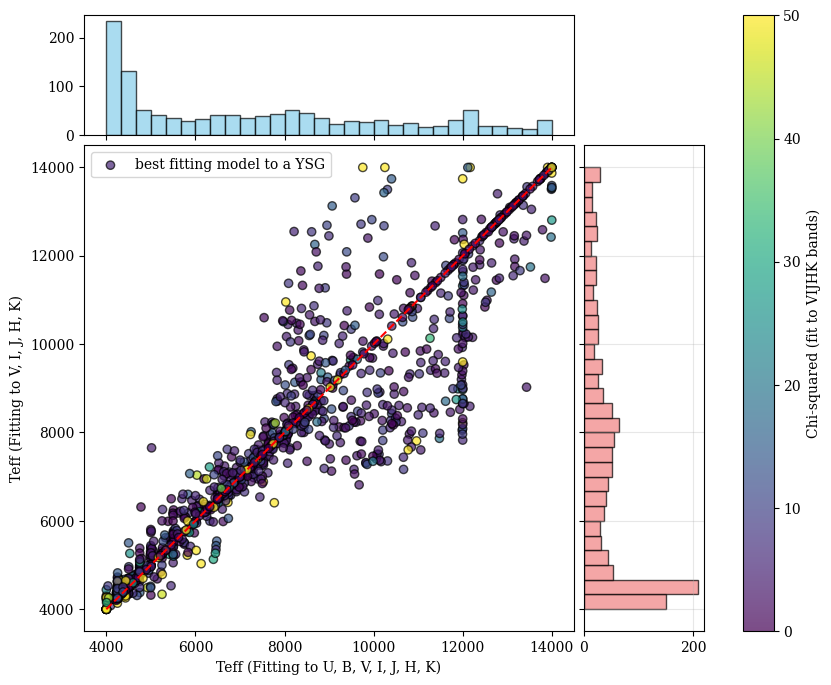

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

cbarmin = 0
cbarmax = 50

fig, ax = plt.subplots(figsize=(10, 8))

# Your existing scatter plot
scatter = ax.scatter(teff_U_redderbands, teff_V_redderbands, c=chi2_V_redder, 
                    edgecolor='k', alpha=0.7, label='best fitting model to a YSG')
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], 
        [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')

# Create marginal axes
divider = make_axes_locatable(ax)
ax_histx = divider.append_axes("top", 1.2, pad=0.1, sharex=ax)
ax_histy = divider.append_axes("right", 1.2, pad=0.1, sharey=ax)

# Add histograms
ax_histx.hist(teff_U_redderbands, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax_histy.hist(teff_V_redderbands, bins=30, orientation='horizontal', 
              alpha=0.7, color='lightcoral', edgecolor='black')

# Hide tick labels on marginal axes
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histy.tick_params(axis="y", labelleft=False)

# Your existing labels and styling
ax.set_xlabel('Teff (Fitting to U, B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to V, I, J, H, K)')
# ax.set_title('Comparison of Teff from most bands vs redder bands')
ax.legend()

# Colorbar
cbar = plt.colorbar(scatter, ax=ax)
scatter.set_clim(cbarmin, cbarmax)
cbar.set_label('Chi-squared (fit to VIJHK bands)')

plt.grid(True, alpha=0.3)
plt.show()

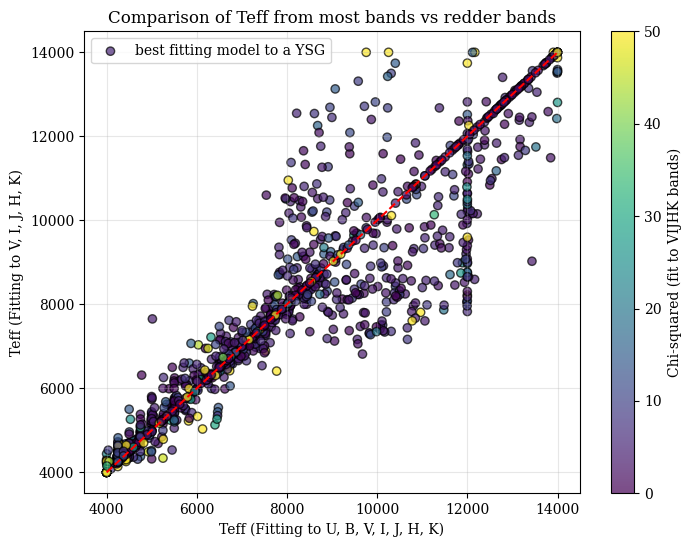

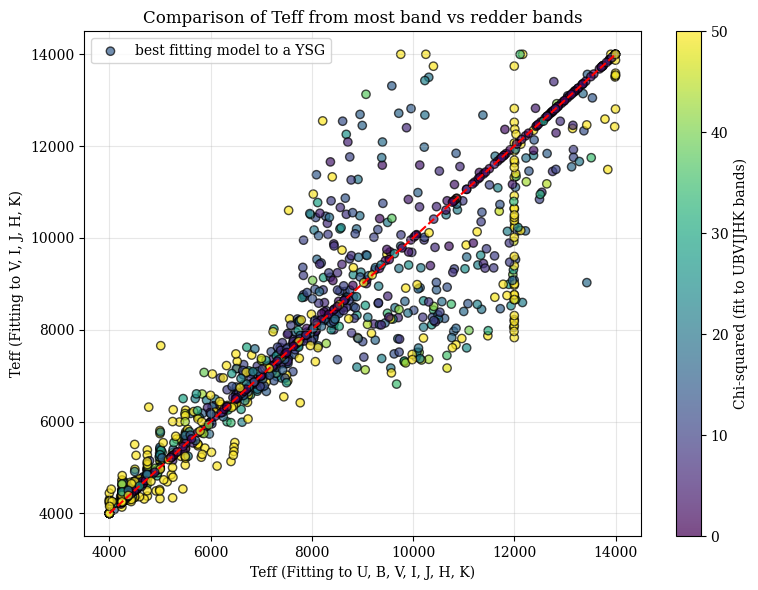

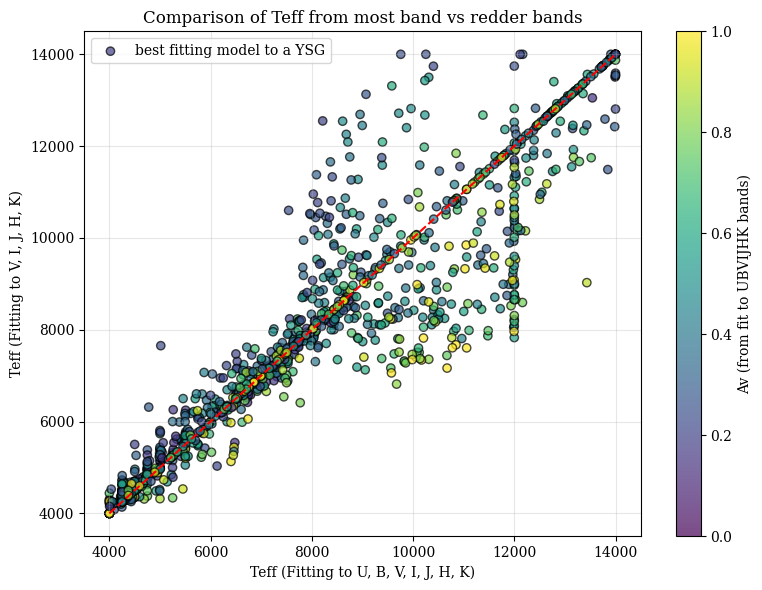

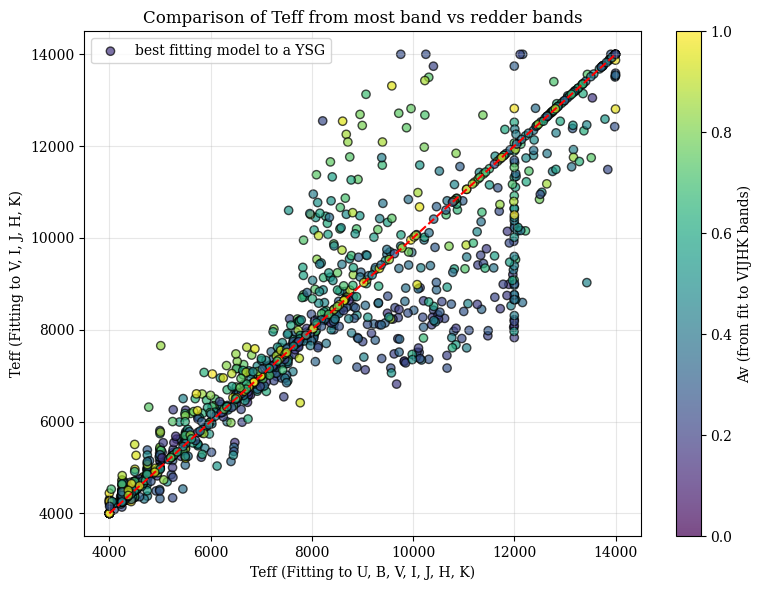

In [ ]:
cbarmin = 0
cbarmax = 50

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(teff_U_redderbands, teff_V_redderbands, c=chi2_V_redder, edgecolor='k', alpha=0.7, label='best fitting model to a YSG')
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')

ax.set_xlabel('Teff (Fitting to U, B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to V, I, J, H, K)')
ax.set_title('Comparison of Teff from most bands vs redder bands')
ax.legend()
cbar = plt.colorbar(ax.collections[0], ax=ax)
ax.collections[0].set_clim(cbarmin, cbarmax)
cbar.set_label('Chi-squared (fit to VIJHK bands)')
plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(teff_U_redderbands, teff_V_redderbands, c=chi2_U_redder, edgecolor='k', alpha=0.7, label='best fitting model to a YSG')
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')
ax.set_xlabel('Teff (Fitting to U, B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to V, I, J, H, K)')
ax.set_title('Comparison of Teff from most band vs redder bands')
ax.legend()
cbar = plt.colorbar(ax.collections[0], ax=ax)
ax.collections[0].set_clim(cbarmin, cbarmax)
cbar.set_label('Chi-squared (fit to UBVIJHK bands)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(teff_U_redderbands, teff_V_redderbands, c=temp_stats['av_mean_U_redder'], edgecolor='k', alpha=0.7, label='best fitting model to a YSG')
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')
ax.set_xlabel('Teff (Fitting to U, B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to V, I, J, H, K)')
ax.set_title('Comparison of Teff from most band vs redder bands')
ax.legend()
cbar = plt.colorbar(ax.collections[0], ax=ax)
ax.collections[0].set_clim(0, 1)
cbar.set_label('Av (from fit to UBVIJHK bands)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(teff_U_redderbands, teff_V_redderbands, c=temp_stats['av_mean_V_redder'], edgecolor='k', alpha=0.7, label='best fitting model to a YSG')
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')
ax.set_xlabel('Teff (Fitting to U, B, V, I, J, H, K)')
ax.set_ylabel('Teff (Fitting to V, I, J, H, K)')
ax.set_title('Comparison of Teff from most band vs redder bands')
ax.legend()
cbar = plt.colorbar(ax.collections[0], ax=ax)
ax.collections[0].set_clim(0, 1)
cbar.set_label('Av (from fit to VIJHK bands)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
counter = 0
for row in temp_stats.itertuples():
    if row.chi2_U_redder_mean < row.chi2_V_redder_mean:
        counter += 1
print(f'Number of stars where fitting to all bands is better: {counter} out of {len(temp_stats)}')

Number of stars where fitting to all bands is better: 3 out of 848


### Comparison to J-K estimates:

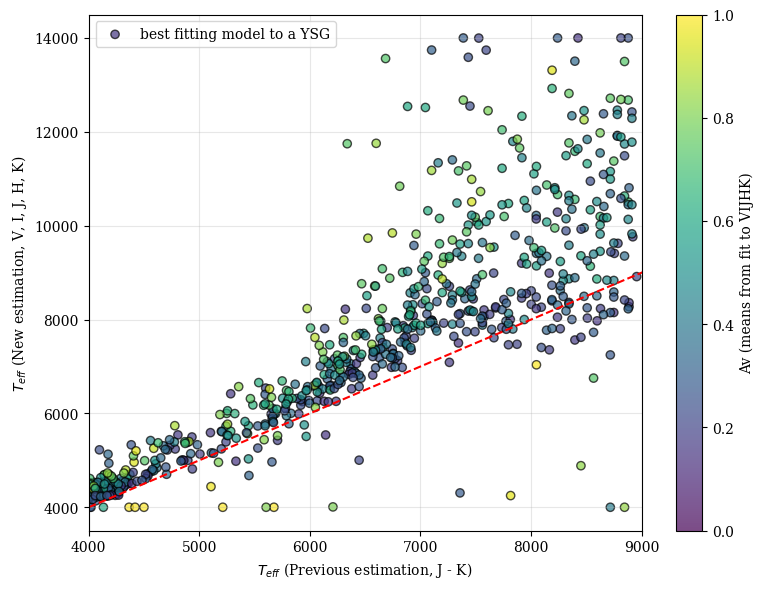

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

periods = stats['best_period']
x_old = stats['logT']
y_old = stats['logL']
teff_V_redderbands = temp_stats['teff_mean_V_redder'][:848]
teff_U_redderbands = temp_stats['teff_mean_U_redder'][:848]


# ax.scatter(10**x_old, teff_V_redderbands, c=chi2_V_redder, edgecolor='k', alpha=0.7, label='best fitting model to a YSG')
ax.scatter(10**x_old, teff_V_redderbands, c=temp_stats['av_mean_V_redder'][:848], edgecolor='k', alpha=0.7, label='best fitting model to a YSG')
ax.plot([min(teff_U_redderbands), max(teff_U_redderbands)], [min(teff_U_redderbands), max(teff_U_redderbands)], 'r--')
ax.set_xlabel('$T_{eff}$ (Previous estimation, J - K)')
ax.set_ylabel('$T_{eff}$ (New estimation, V, I, J, H, K)')
# ax.set_title('Comparison of Teff, old vs new estimations')
ax.legend()
# change colourmap to plasma
plt.set_cmap('Reds')
cbar = plt.colorbar(ax.collections[0], cmap='Reds', ax=ax)
# ax.collections[0].set_clim(cbarmin, cbarmax)
ax.collections[0].set_clim(0, 1)
cbar.set_label('Av (means from fit to VIJHK)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.xlim(4000, 9000)
# plt.save_fig()
plt.show()

/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_99291/3281616026.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc1 = ax1.scatter(x_old, y_old, edgecolor='k', label='old estimations', alpha=0.7, cmap='inferno')


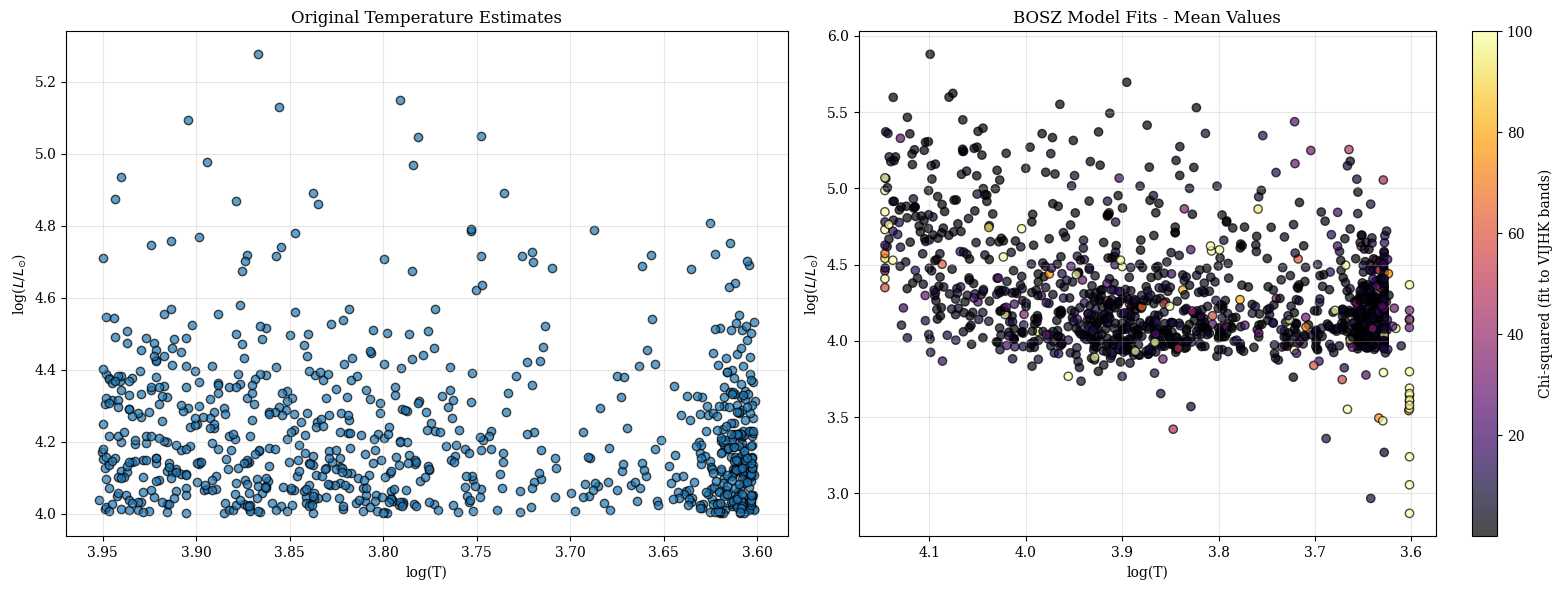

In [ ]:
logT = temp_stats['logT_mean_V_redder']
logL = temp_stats['logL_mean_V_redder']
chi2_V_redder = temp_stats['chi2_V_redder_mean']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Old estimations
periods = stats['best_period']
x_old = stats['logT']
y_old = stats['logL']
sc1 = ax1.scatter(x_old, y_old, edgecolor='k', label='old estimations', alpha=0.7, cmap='inferno')
ax1.set_xlabel('log(T)')
ax1.set_ylabel('log($L/L_{\\odot}$)')
ax1.set_title('Original Temperature Estimates')
ax1.invert_xaxis()
ax1.grid(True, alpha=0.3)

sc = ax2.scatter(logT, logL, c=chi2_V_redder, edgecolor='k', label='new estimations', alpha=0.7, cmap='inferno', vmax=100)
# sc2 = ax2.scatter(logT.iloc[444], logL.iloc[444], c='red', edgecolor='k', label='target star 444')
# sc2 = ax2.scatter(logT.iloc[726], logL.iloc[726], c='red', edgecolor='k', label='target star 726')
ax2.set_xlabel('log(T)')
ax2.set_ylabel('log($L/L_{\\odot}$)')
ax2.set_title('BOSZ Model Fits - Mean Values')
ax2.invert_xaxis()
ax2.grid(True, alpha=0.3)
cbar = plt.colorbar(sc, ax=ax2)
cbar.set_label('Chi-squared (fit to VIJHK bands)')
# cbar.set_label('Period (days)')
plt.tight_layout()
plt.show()

### Wacky change-tracking diagram:

/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_99291/57881391.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


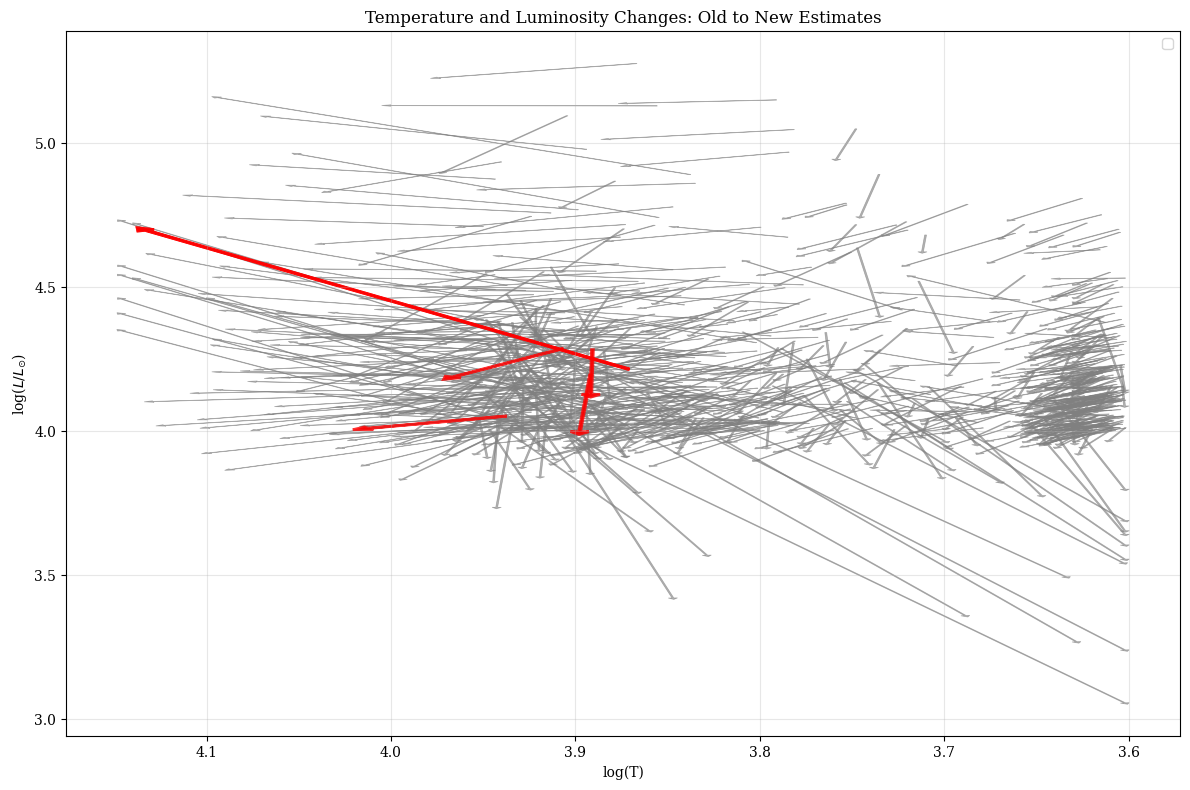

In [ ]:
logT = temp_stats['logT_mean_V_redder']
logL = temp_stats['logL_mean_V_redder']

# Old estimations
periods = stats['best_period']
x_old = stats['logT']
y_old = stats['logL']

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

for i in range(len(x_old)):
    dx = logT.iloc[i] - x_old.iloc[i]
    dy = logL.iloc[i] - y_old.iloc[i]

    ax.arrow(x_old.iloc[i], y_old.iloc[i], dx, dy,
            head_width=0.005, head_length=0.005, 
            fc='gray', ec='gray', alpha=0.6, linewidth=0.5)

dx_444 = logT.iloc[444] - x_old.iloc[444]
dy_444 = logL.iloc[444] - y_old.iloc[444]
ax.arrow(x_old.iloc[444], y_old.iloc[444], dx_444, dy_444,
        head_width=0.01, head_length=0.01, 
        fc='red', ec='red', alpha=0.8, linewidth=2)

dx_726 = logT.iloc[726] - x_old.iloc[726]
dy_726 = logL.iloc[726] - y_old.iloc[726]
ax.arrow(x_old.iloc[726], y_old.iloc[726], dx_726, dy_726,
        head_width=0.01, head_length=0.01, 
        fc='red', ec='red', alpha=0.8, linewidth=2)

dx_495 = logT.iloc[495] - x_old.iloc[495]
dy_495 = logL.iloc[495] - y_old.iloc[495]
ax.arrow(x_old.iloc[495], y_old.iloc[495], dx_495, dy_495,
        head_width=0.01, head_length=0.01, 
        fc='red', ec='red', alpha=0.8, linewidth=2)

dx_802 = logT.iloc[802] - x_old.iloc[802]
dy_802 = logL.iloc[802] - y_old.iloc[802]
ax.arrow(x_old.iloc[802], y_old.iloc[802], dx_802, dy_802,
        head_width=0.01, head_length=0.01, 
        fc='red', ec='red', alpha=0.8, linewidth=2)

dx_802 = logT.iloc[802] - x_old.iloc[802]
dy_802 = logL.iloc[802] - y_old.iloc[802]
ax.arrow(x_old.iloc[802], y_old.iloc[802], dx_802, dy_802,
        head_width=0.01, head_length=0.01, 
        fc='red', ec='red', alpha=0.8, linewidth=2)
dx_79 = logT.iloc[79] - x_old.iloc[79]
dy_79 = logL.iloc[79] - y_old.iloc[79]
ax.arrow(x_old.iloc[79], y_old.iloc[79], dx_79, dy_79,
        head_width=0.01, head_length=0.01, 
        fc='red', ec='red', alpha=0.8, linewidth=2)


ax.set_xlabel('log(T)')
ax.set_ylabel('log($L/L_{\\odot}$)')
ax.set_title('Temperature and Luminosity Changes: Old to New Estimates')
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
ax.legend()

# cbar = plt.colorbar(sc1, ax=ax)
# cbar.set_label('Period (days)')
plt.tight_layout()
plt.show()

In [ ]:
# Read both CSV files
summary_results = pd.read_csv('../summary_results15.csv')
temp_fitting = pd.read_csv('ysg_temp_fitting_summary_v8_prefinal.csv')

# # Merge the dataframes on RA and DEC
# # Using a left join to keep all rows from temp_fitting
# merged = temp_fitting.merge(
#     summary_results[['RA', 'DEC', 'mag_amplitude_1']], 
#     on=['RA', 'DEC'], 
#     how='left'
# )

# # Write the result back to the file
# merged.to_csv('ysg_temp_fitting_summary_v8_prefinal.csv', index=False)

# print(f"Successfully added columns to ysg_temp_fitting_summary_v8_prefinal.csv")
# print(f"Total rows: {len(merged)}")

Successfully added columns to ysg_temp_fitting_summary_v8_prefinal.csv
Total rows: 1270
